In [1]:
import pandas as pd 

df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/final_SP_Choice_Graph.csv')

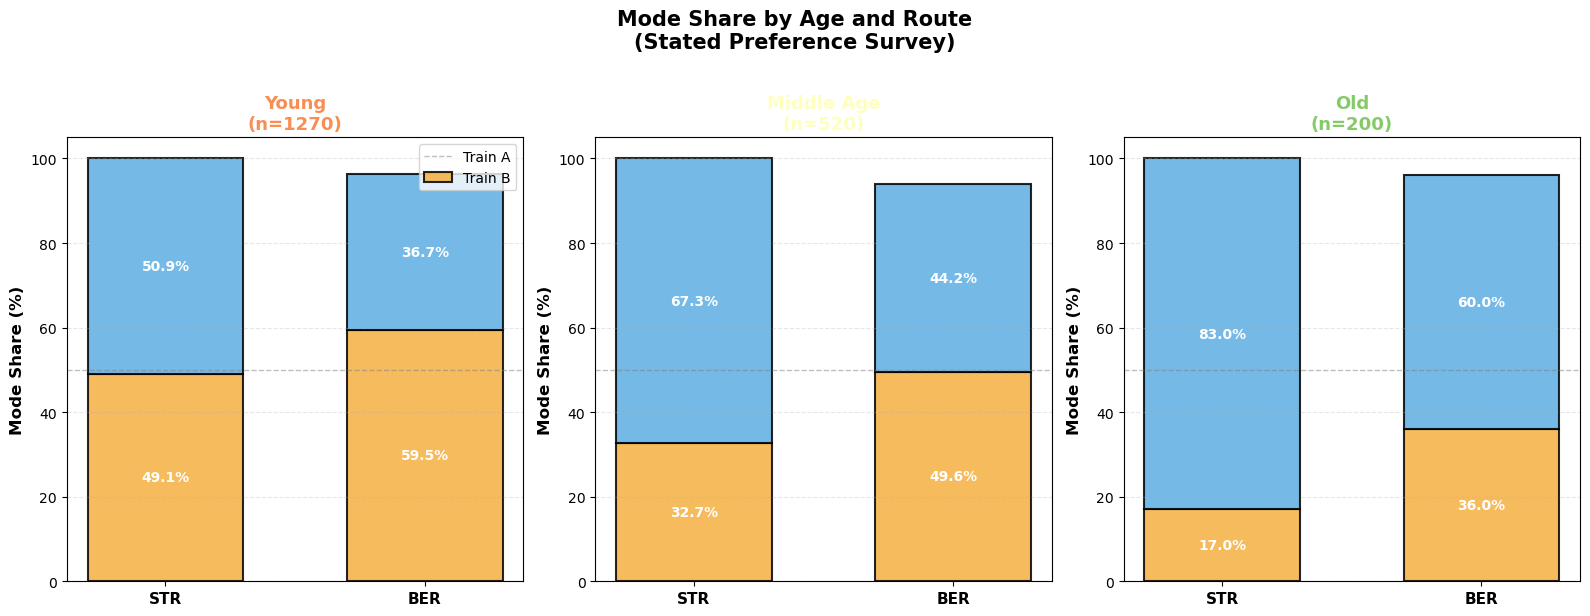

Plot saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/choice_by_age.png


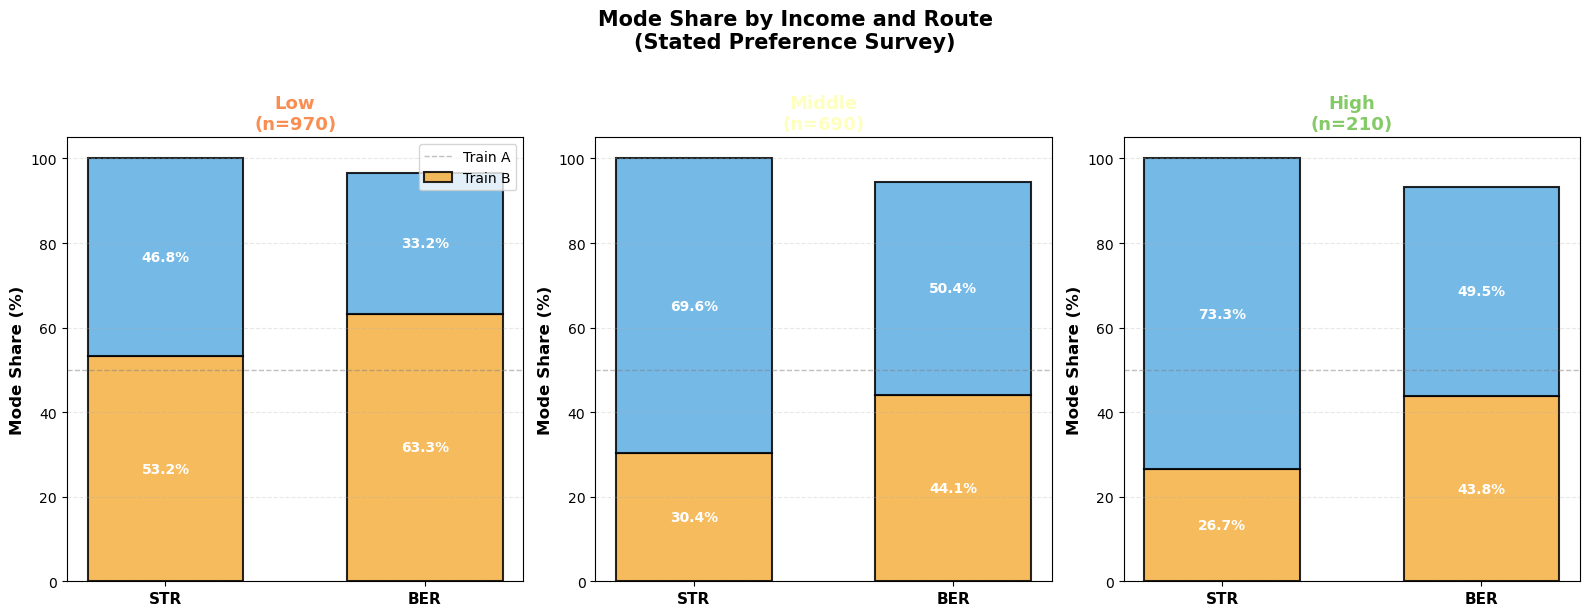

Plot saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/choice_by_income.png


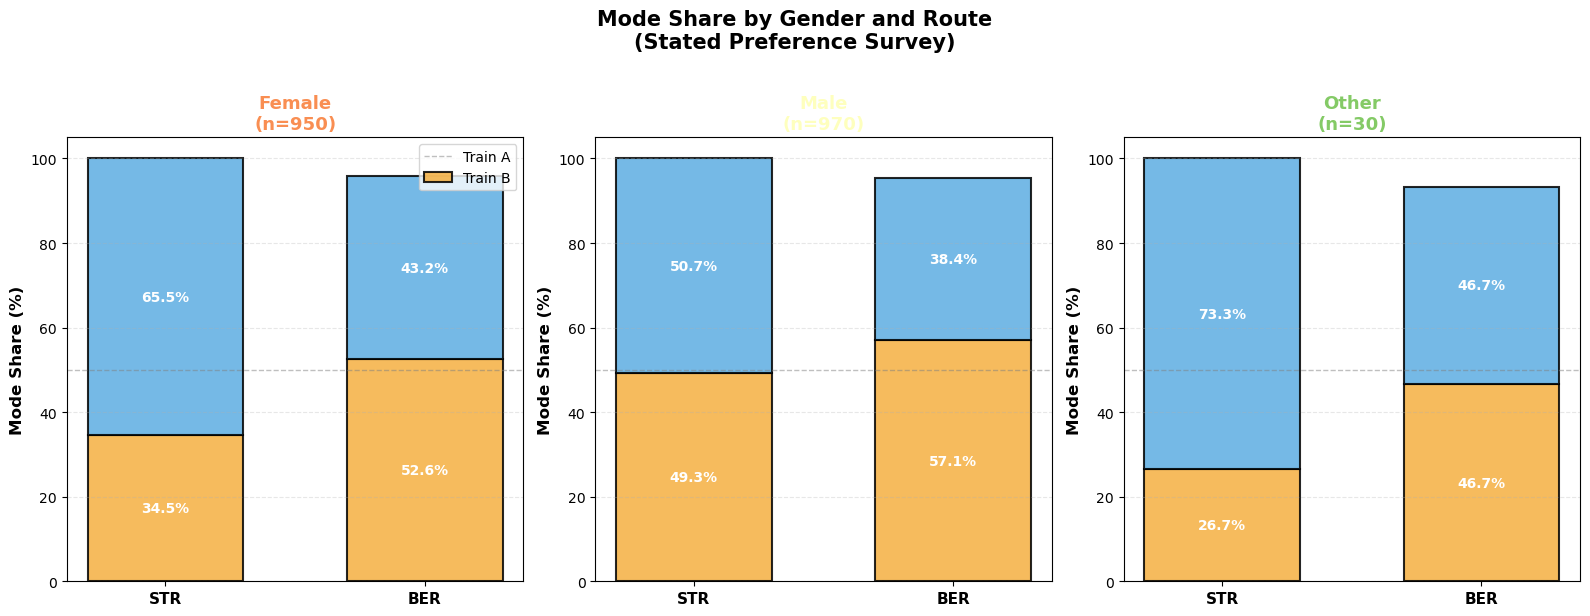

Plot saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/choice_by_gender.png


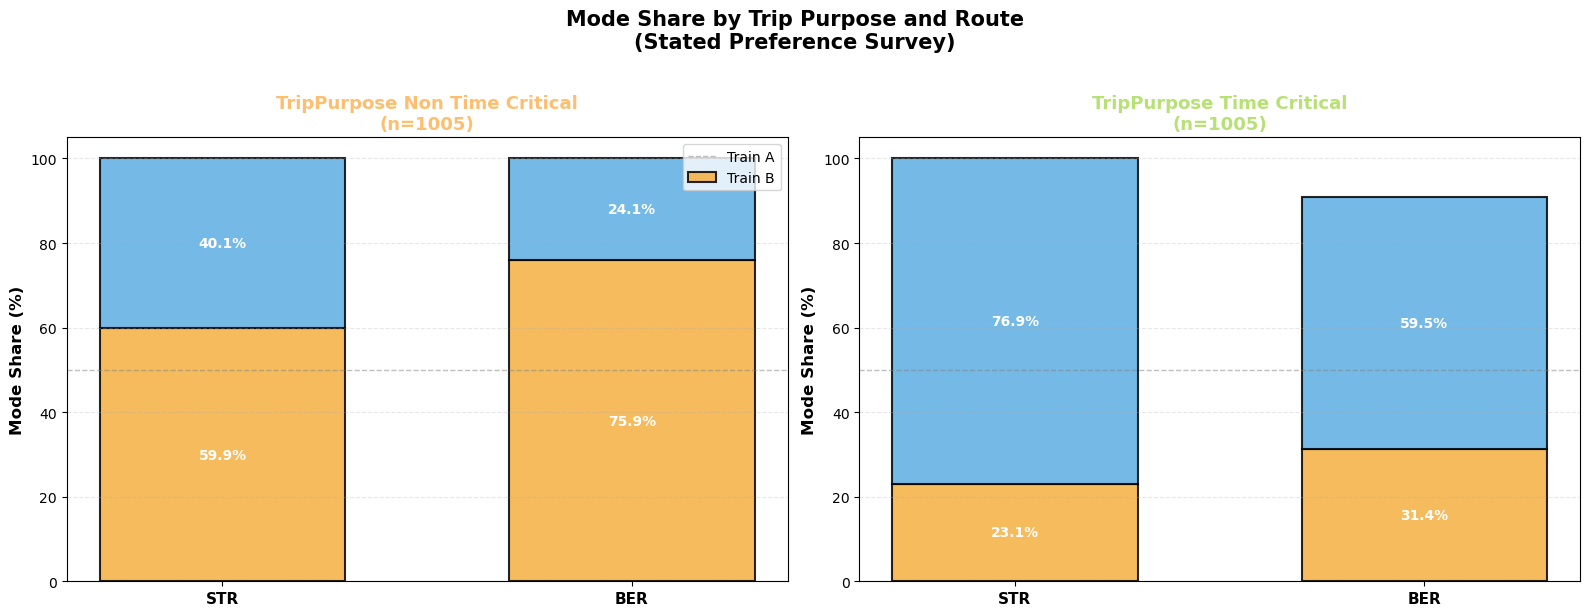

Plot saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/choice_by_trip_purpose.png


In [5]:
##PERP_PLOT
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle

# Define sociodemographic variables and their categories
socio_variables = {
    'Age': ['Age_Young', 'Age_Middle_Age', 'Age_Old'],
    'Income': ['Income_Low', 'Income_Middle', 'Income_High'],
    'Gender': ['Gender_Female', 'Gender_Male', 'Gender_Other'],
    'Trip Purpose': ['TripPurpose_Non_Time_Critical', 'TripPurpose_Time_Critical']
}

routes = ['STR', 'BER']
route_labels = {1: 'STR', 0: 'BER'}  # Adjust based on your binary coding

def plot_choice_by_socio_variable(df, variable_name, variable_columns, save_path=None):
    """
    Plot mode share (Train A vs Train B) by sociodemographic variable and route.
    
    Parameters:
    - variable_name: Name of the sociodemographic variable (e.g., 'Age')
    - variable_columns: List of binary-encoded columns for this variable
    - save_path: Path to save the figure
    """
    
    fig, axes = plt.subplots(1, len(variable_columns), figsize=(16, 6))
    if len(variable_columns) == 1:
        axes = [axes]
    
    # Color palette for gradient effect across categories
    colors = sns.color_palette("RdYlGn", len(variable_columns))
    
    for idx, col in enumerate(variable_columns):
        category_name = col.replace(f'{variable_name}_', '').replace('_', ' ')
        
        # Filter data for this category
        filtered_df = df[df[col] == 1].copy()
        
        if len(filtered_df) == 0:
            axes[idx].text(0.5, 0.5, f'No data for {category_name}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            continue
        
        # Calculate choice shares for each route
        data_for_plot = []
        
        for route in routes:
            route_data = filtered_df[filtered_df[route] == 1]
            
            total_choices = len(route_data)
            if total_choices > 0:
                zug_a_share = (route_data['Choice_ZugA'].sum() / total_choices) * 100
                zug_b_share = (route_data['Choice_ZugB'].sum() / total_choices) * 100
                
                data_for_plot.append({
                    'Route': route_labels.get(route, route),
                    'Train A': zug_a_share,
                    'Train B': zug_b_share,
                    'Count': total_choices
                })
        
        # Plot grouped stacked bars
        plot_df = pd.DataFrame(data_for_plot)
        
        x_pos = np.arange(len(plot_df))
        bar_width = 0.6
        
        # Stacked bars
        ax = axes[idx]
        p1 = ax.bar(x_pos, plot_df['Train A'], bar_width, 
                    label='Train A', color='#F5B041', alpha=0.85, edgecolor='black', linewidth=1.5)
        p2 = ax.bar(x_pos, plot_df['Train B'], bar_width, bottom=plot_df['Train A'],
                    label='Train B', color='#5DADE2', alpha=0.85, edgecolor='black', linewidth=1.5)
        
        # Add percentage labels on bars
        for i, (idx_bar, row) in enumerate(plot_df.iterrows()):
            # Train A percentage
            if row['Train A'] > 5:  # Only show if significant
                ax.text(i, row['Train A']/2, f"{row['Train A']:.1f}%", 
                       ha='center', va='center', fontweight='bold', fontsize=10, color='white')
            # Train B percentage
            if row['Train B'] > 5:
                ax.text(i, row['Train A'] + row['Train B']/2, f"{row['Train B']:.1f}%", 
                       ha='center', va='center', fontweight='bold', fontsize=10, color='white')
        
        # Formatting
        ax.set_ylim(0, 105)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([row['Route'] for _, row in plot_df.iterrows()], fontsize=11, fontweight='bold')
        ax.set_ylabel('Mode Share (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{category_name}\n(n={plot_df["Count"].sum()})', 
                    fontsize=13, fontweight='bold', color=colors[idx])
        ax.set_ylim(0, 105)
        ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        if idx == 0:
            ax.legend(['Train A', 'Train B'], loc='upper right', fontsize=10)
    
    plt.suptitle(f'Mode Share by {variable_name} and Route\n(Stated Preference Survey)', 
                fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig


# Generate plots for each sociodemographic variable
for var_name, var_columns in socio_variables.items():
    save_path = f'/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/choice_by_{var_name.lower().replace(" ", "_")}.png'
    plot_choice_by_socio_variable(df, var_name, var_columns, save_path=save_path)
    print(f"Plot saved: {save_path}")


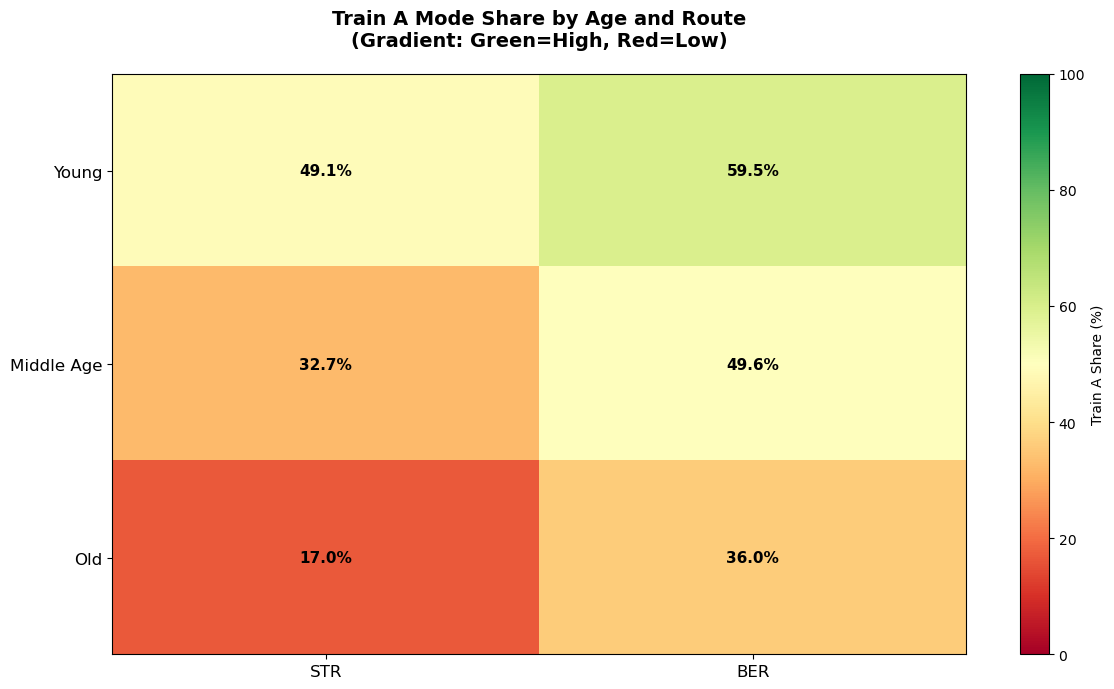

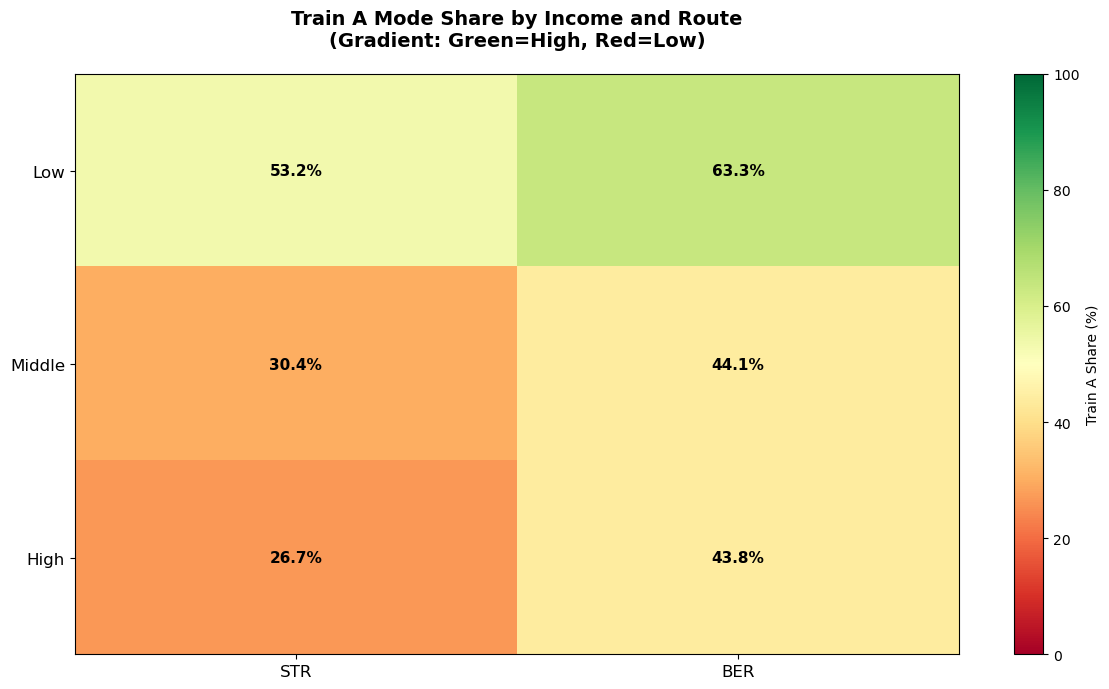

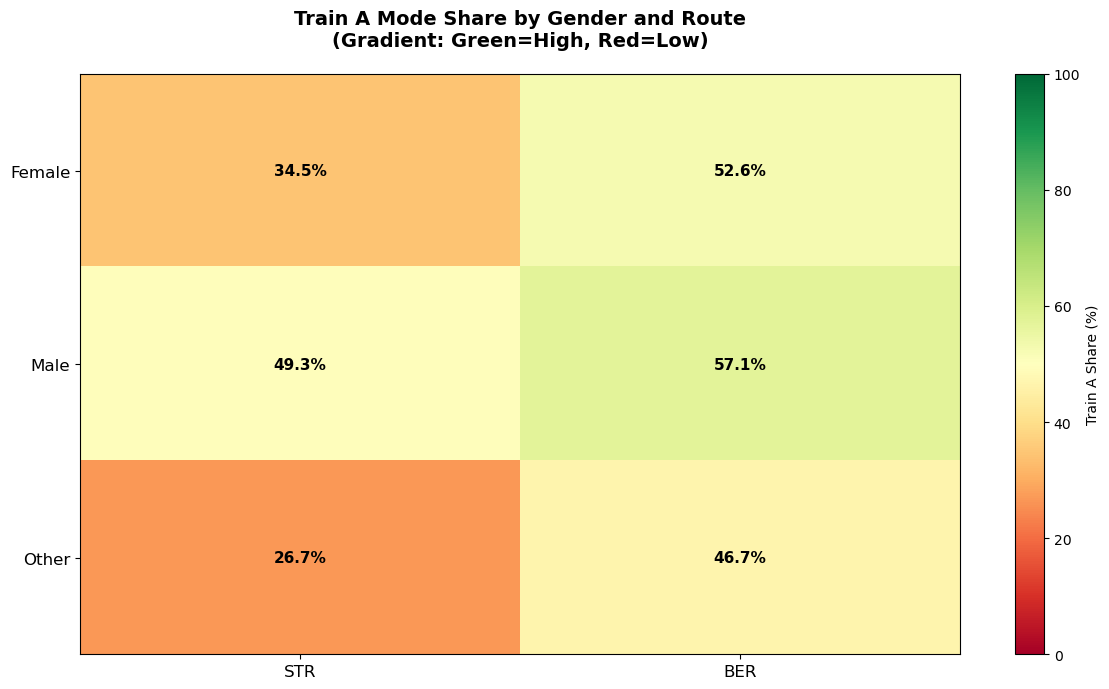

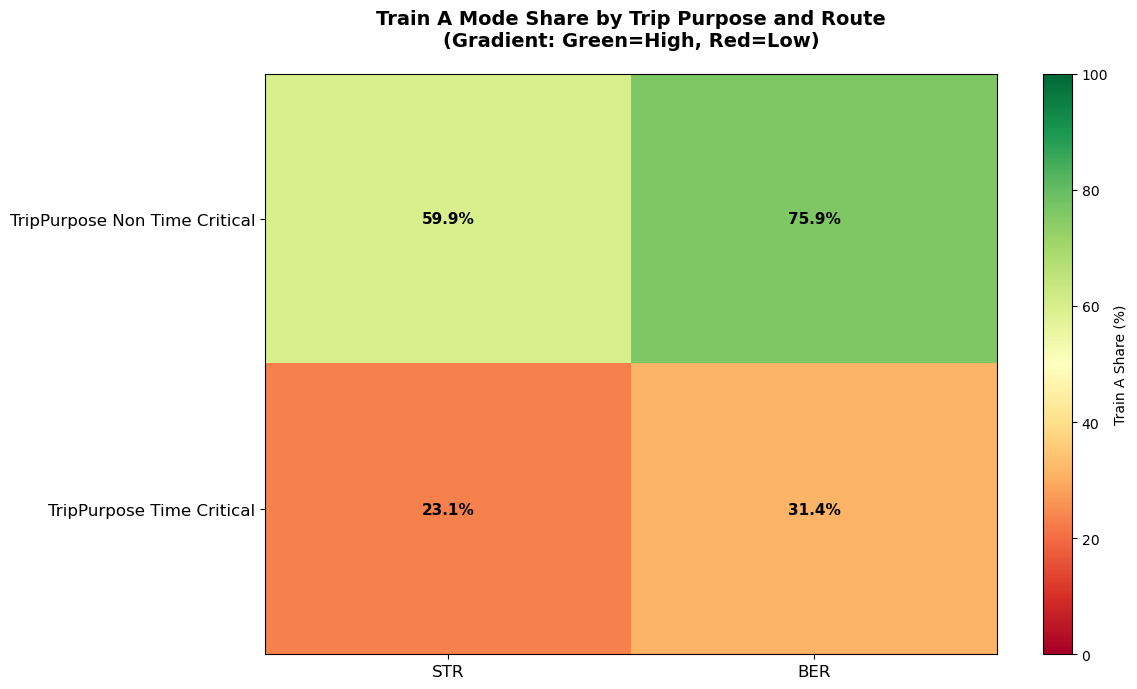

In [7]:
##PERPX_DEEP_HEATMAPS

def plot_choice_heatmap_by_variable(df, variable_name, variable_columns, save_path=None):
    """
    Create a heatmap-style visualization showing choice behavior across 
    sociodemographic categories and routes with gradient coloring.
    """
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Prepare data matrix
    data_matrix = []
    row_labels = []
    
    for col in variable_columns:
        category_name = col.replace(f'{variable_name}_', '').replace('_', ' ')
        
        for route in routes:
            filtered_df = df[(df[col] == 1) & (df[route] == 1)]
            
            if len(filtered_df) > 0:
                zug_a_share = (filtered_df['Choice_ZugA'].sum() / len(filtered_df)) * 100
                data_matrix.append(zug_a_share)
                row_labels.append(f"{category_name} - {route_labels.get(route, route)}")
    
    # Reshape for heatmap
    data_matrix = np.array(data_matrix).reshape(len(variable_columns), len(routes))
    
    # Create heatmap
    im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(routes)))
    ax.set_yticks(np.arange(len(variable_columns)))
    ax.set_xticklabels([route_labels.get(r, r) for r in routes], fontsize=12)
    ax.set_yticklabels([col.replace(f'{variable_name}_', '').replace('_', ' ') 
                        for col in variable_columns], fontsize=12)
    
    # Add text annotations
    for i in range(len(variable_columns)):
        for j in range(len(routes)):
            text = ax.text(j, i, f'{data_matrix[i, j]:.1f}%',
                          ha="center", va="center", color="black", fontweight='bold', fontsize=11)
    
    ax.set_title(f'Train A Mode Share by {variable_name} and Route\n(Gradient: Green=High, Red=Low)', 
                fontsize=14, fontweight='bold', pad=20)
    
    cbar = plt.colorbar(im, ax=ax, label='Train A Share (%)')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


# Generate heatmaps
for var_name, var_columns in socio_variables.items():
    save_path = f'/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/heatmap_{var_name.lower().replace(" ", "_")}.png'
    plot_choice_heatmap_by_variable(df, var_name, var_columns, save_path=save_path)


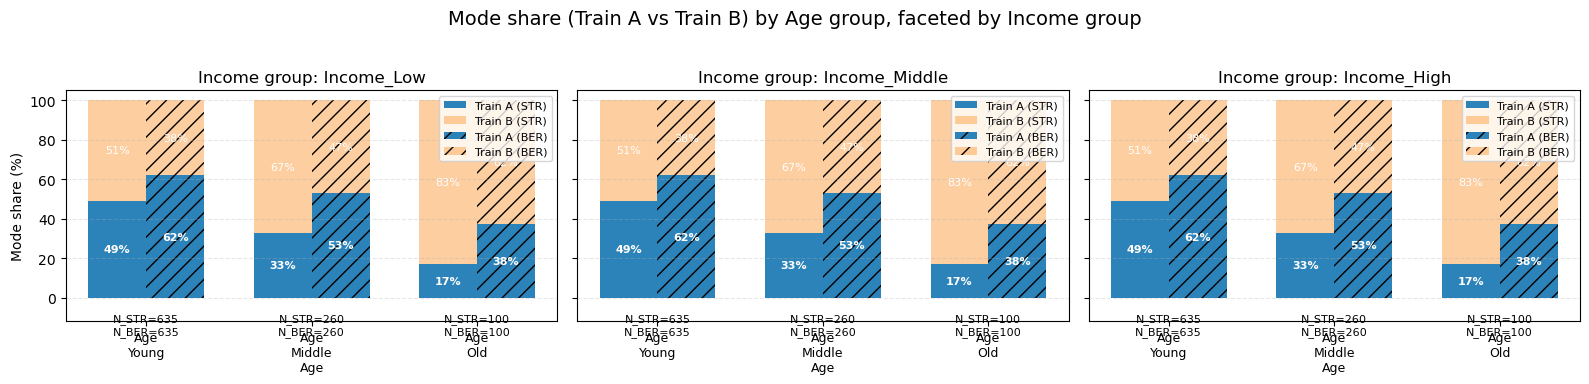

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_6196/1802390297.py:191: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap(cmap, nsec)


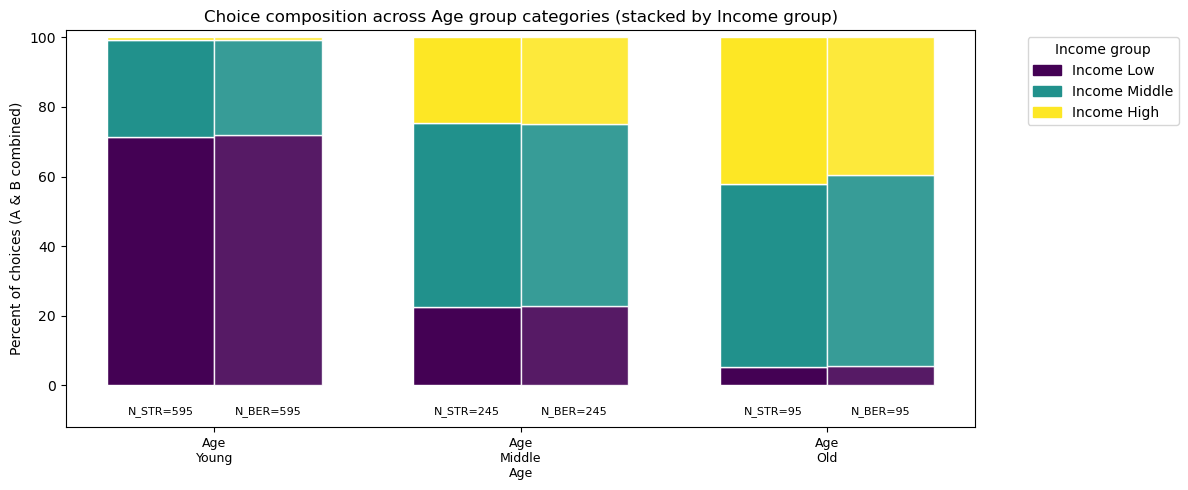

In [13]:
#GT_PLOT
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib.colors import ListedColormap

# Load data
# --- Utility: robustly find or build Choice_A / Choice_B and route flags STR / BER ---
def prepare_df(df):
    df = df.copy()
    cols = {c.lower(): c for c in df.columns}

    # Choice columns
    if 'choice_zuga' in cols and 'choice_zugb' in cols:
        df['Choice_A'] = df[cols['choice_zuga']]
        df['Choice_B'] = df[cols['choice_zugb']]
    elif 'choice_zug_a' in cols and 'choice_zug_b' in cols:
        df['Choice_A'] = df[cols['choice_zug_a']]
        df['Choice_B'] = df[cols['choice_zug_b']]
    else:
        # fallback: collect any columns that contain 'choice' and 'zug' and 'a' or 'b'
        cols_a = [c for c in df.columns if re.search(r'choice.*zug.*a', c, flags=re.I)]
        cols_b = [c for c in df.columns if re.search(r'choice.*zug.*b', c, flags=re.I)]
        if cols_a:
            df['Choice_A'] = df[cols_a].sum(axis=1)
        if cols_b:
            df['Choice_B'] = df[cols_b].sum(axis=1)

    if 'Choice_A' not in df.columns or 'Choice_B' not in df.columns:
        raise ValueError("Could not detect choice columns for A/B. Please ensure CSV contains Choice_ZugA/Choice_ZugB or choice_zug_A_* / choice_zug_B_* columns.")

    # binarize ( >0 -> 1 ) so one-hot sums are robust
    df['Choice_A'] = (df['Choice_A'] > 0).astype(int)
    df['Choice_B'] = (df['Choice_B'] > 0).astype(int)

    # Routes
    if 'str' in cols:
        route_str = cols['str']
    elif 'STR' in df.columns:
        route_str = 'STR'
    else:
        raise ValueError("STR route column not found.")
    if 'ber' in cols:
        route_ber = cols['ber']
    elif 'BER' in df.columns:
        route_ber = 'BER'
    else:
        raise ValueError("BER route column not found.")

    # ensure binary
    df[route_str] = (df[route_str] > 0).astype(int)
    df[route_ber] = (df[route_ber] > 0).astype(int)

    return df, route_str, route_ber

df, route_STR_col, route_BER_col = prepare_df(df)

# -------------------------
# Function 1: Faceted bars (recommended)
# -------------------------
def plot_faceted_by_secondary(df, primary_group_cols, secondary_group_cols,
                              route_cols=(route_STR_col, route_BER_col),
                              primary_label="Primary", secondary_label="Secondary",
                              filter_col=None, filter_value=None,
                              figsize=(14, 4), cmap='Blues'):
    """
    For each category column in primary_group_cols (one-hot),
    produce a grouped bar with two bars (STR and BER) showing stacked share of Choice_A and Choice_B.
    Facet the figure by each level in secondary_group_cols (one-hot).
    If filter_col/filter_value are provided, data is filtered first (e.g., TripPurpose_Time_Critical == 1).
    """
    # Optional filter
    data = df.copy()
    if filter_col is not None:
        data = data.loc[data[filter_col] == filter_value].copy()

    # Validate inputs
    if any(c not in data.columns for c in primary_group_cols):
        missing = [c for c in primary_group_cols if c not in data.columns]
        raise ValueError(f"Missing primary columns: {missing}")
    if any(c not in data.columns for c in secondary_group_cols):
        missing = [c for c in secondary_group_cols if c not in data.columns]
        raise ValueError(f"Missing secondary columns: {missing}")

    n_secondary = len(secondary_group_cols)
    fig, axes = plt.subplots(1, n_secondary, figsize=figsize, sharey=True)
    if n_secondary == 1:
        axes = [axes]

    # Colors for A and B
    colors = ['#2b83ba', '#fdae61']  # A (blue), B (orange)

    for ax, sec_col in zip(axes, secondary_group_cols):
        sec_label = sec_col
        # for each primary category, compute percentages by route
        A_vals_STR, B_vals_STR, Ns_STR = [], [], []
        A_vals_BER, B_vals_BER, Ns_BER = [], [], []
        labels = []
        for pcol in primary_group_cols:
            labels.append(pcol.replace('_', '\n'))  # short label for xticks
            sel = data[ data[ pcol ] == 1 ]
            # STR subset
            sub_STR = sel[ sel[ route_STR_col ] == 1 ]
            a_count = sub_STR['Choice_A'].sum()
            b_count = sub_STR['Choice_B'].sum()
            total = a_count + b_count
            if total == 0:
                A_vals_STR.append(np.nan); B_vals_STR.append(np.nan); Ns_STR.append(0)
            else:
                A_vals_STR.append(100*a_count/total); B_vals_STR.append(100*b_count/total); Ns_STR.append(len(sub_STR))

            # BER subset
            sub_BER = sel[ sel[ route_BER_col ] == 1 ]
            a_count = sub_BER['Choice_A'].sum()
            b_count = sub_BER['Choice_B'].sum()
            total = a_count + b_count
            if total == 0:
                A_vals_BER.append(np.nan); B_vals_BER.append(np.nan); Ns_BER.append(0)
            else:
                A_vals_BER.append(100*a_count/total); B_vals_BER.append(100*b_count/total); Ns_BER.append(len(sub_BER))

        x = np.arange(len(primary_group_cols))
        width = 0.35

        # Bars for STR (left) and BER (right)
        ax.bar(x - width/2, A_vals_STR, width, color=colors[0], label='Train A (STR)')
        ax.bar(x - width/2, B_vals_STR, width, bottom=np.nan_to_num(A_vals_STR), color=colors[1], alpha=0.6, label='Train B (STR)')

        ax.bar(x + width/2, A_vals_BER, width, color=colors[0], hatch='//', label='Train A (BER)')
        ax.bar(x + width/2, B_vals_BER, width, bottom=np.nan_to_num(A_vals_BER), color=colors[1], alpha=0.6, hatch='//', label='Train B (BER)')

        # Annotate percentages and Ns
        for i in range(len(x)):
            # STR annotations
            if not np.isnan(A_vals_STR[i]):
                ax.text(x[i]-width/2, A_vals_STR[i]/2, f"{A_vals_STR[i]:.0f}%", ha='center', va='center', color='white', fontsize=8, fontweight='bold')
            if not np.isnan(B_vals_STR[i]):
                ax.text(x[i]-width/2, A_vals_STR[i] + B_vals_STR[i]/2, f"{B_vals_STR[i]:.0f}%", ha='center', va='center', color='white', fontsize=8)
            # BER annotations
            if not np.isnan(A_vals_BER[i]):
                ax.text(x[i]+width/2, A_vals_BER[i]/2, f"{A_vals_BER[i]:.0f}%", ha='center', va='center', color='white', fontsize=8, fontweight='bold')
            if not np.isnan(B_vals_BER[i]):
                ax.text(x[i]+width/2, A_vals_BER[i] + B_vals_BER[i]/2, f"{B_vals_BER[i]:.0f}%", ha='center', va='center', color='white', fontsize=8)
            # sample sizes below
            ax.text(x[i], -8, f"N_STR={Ns_STR[i]}\nN_BER={Ns_BER[i]}", ha='center', va='top', fontsize=8)

        ax.set_title(f"{secondary_label}: {sec_col}")
        ax.set_xticks(x)
        ax.set_xticklabels([c.replace('_','\n') for c in primary_group_cols], rotation=0, fontsize=9)
        ax.set_ylim(-12, 105)
        ax.set_ylabel("Mode share (%)" if ax is axes[0] else "")
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.legend(loc='upper right', fontsize=8)

    plt.suptitle(f"Mode share (Train A vs Train B) by {primary_label}, faceted by {secondary_label}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# -------------------------
# Function 2: Single stacked bars with internal secondary breakdown
# -------------------------
def plot_subdivided_bars(df, primary_group_cols, secondary_group_cols,
                         route_cols=(route_STR_col, route_BER_col),
                         primary_label="Primary", secondary_label="Secondary",
                         filter_col=None, filter_value=None,
                         figsize=(12, 5),
                         cmap='viridis'):
    """
    More compact: For each primary category, produce two bars (STR, BER).
    Each bar is subdivided into stacked segments representing (Choice × secondary-level).
    The whole bar sums to 100 (A and B combined), and the internal segments show composition by secondary categories.
    """
    data = df.copy()
    if filter_col is not None:
        data = data.loc[data[filter_col] == filter_value].copy()

    # validate
    if any(c not in data.columns for c in primary_group_cols):
        missing = [c for c in primary_group_cols if c not in data.columns]
        raise ValueError(f"Missing primary columns: {missing}")
    if any(c not in data.columns for c in secondary_group_cols):
        missing = [c for c in secondary_group_cols if c not in data.columns]
        raise ValueError(f"Missing secondary columns: {missing}")

    # Build color map for secondary levels
    nsec = len(secondary_group_cols)
    base_cmap = plt.cm.get_cmap(cmap, nsec)
    sec_colors = [base_cmap(i) for i in range(nsec)]

    labels = [c.replace('_','\n') for c in primary_group_cols]
    x = np.arange(len(primary_group_cols))
    width = 0.35

    fig, ax = plt.subplots(figsize=figsize)

    # For each primary category, produce stacked segment heights for STR and BER
    for i, pcol in enumerate(primary_group_cols):
        sel = data[ data[pcol] == 1 ]
        # We'll create an ordered list of segments: [(sec1-A),(sec2-A),...,(secN-A),(sec1-B),(sec2-B),...]
        segs_STR = []
        segs_BER = []
        Ns_STR = 0
        Ns_BER = 0
        # first compute counts per sec-level for Choice A and B in STR and BER
        for s_idx, scol in enumerate(secondary_group_cols):
            # STR subset for this primary and secondary level
            sub_STR = sel[(sel[route_STR_col] == 1) & (sel[scol] == 1)]
            a_count = sub_STR['Choice_A'].sum()
            b_count = sub_STR['Choice_B'].sum()
            Ns_STR += len(sub_STR)
            segs_STR.append( (a_count, b_count) )
            # BER
            sub_BER = sel[(sel[route_BER_col] == 1) & (sel[scol] == 1)]
            a_count = sub_BER['Choice_A'].sum()
            b_count = sub_BER['Choice_B'].sum()
            Ns_BER += len(sub_BER)
            segs_BER.append( (a_count, b_count) )

        # Totals for normalization
        total_STR = sum(a+b for a,b in segs_STR)
        total_BER = sum(a+b for a,b in segs_BER)

        # Build stacked segments (convert to percent of total A+B for that bar)
        # If total==0, produce empty bar
        bottom_STR = 0.0
        bottom_BER = 0.0
        for s_idx, scol in enumerate(secondary_group_cols):
            a_cnt, b_cnt = segs_STR[s_idx]
            seg_val = (a_cnt + b_cnt) * 100.0 / total_STR if total_STR>0 else 0.0
            ax.bar(i - width/2, seg_val, width, bottom=bottom_STR, color=sec_colors[s_idx], edgecolor='white')
            bottom_STR += seg_val

        for s_idx, scol in enumerate(secondary_group_cols):
            a_cnt, b_cnt = segs_BER[s_idx]
            seg_val = (a_cnt + b_cnt) * 100.0 / total_BER if total_BER>0 else 0.0
            ax.bar(i + width/2, seg_val, width, bottom=bottom_BER, color=sec_colors[s_idx], edgecolor='white', alpha=0.9)
            bottom_BER += seg_val

        # Annotate sample sizes
        ax.text(i - width/2, -6, f"N_STR={Ns_STR}", ha='center', va='top', fontsize=8)
        ax.text(i + width/2, -6, f"N_BER={Ns_BER}", ha='center', va='top', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(-12, 102)
    ax.set_ylabel("Percent of choices (A & B combined)")

    # Legend: secondary categories
    legend_patches = [plt.Rectangle((0,0),1,1, color=sec_colors[i]) for i in range(nsec)]
    sec_names = [c.replace('_',' ') for c in secondary_group_cols]
    ax.legend(legend_patches, sec_names, title=secondary_label, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title(f"Choice composition across {primary_label} categories (stacked by {secondary_label})")
    plt.tight_layout()
    plt.show()

# -------------------------
# Example usage
# -------------------------
# Suppose you want to examine Age groups (primary) and Income groups (secondary), and filter to time-critical trips only:
age_cols = ["Age_Young", "Age_Middle_Age", "Age_Old"]
income_cols = ["Income_Low", "Income_Middle", "Income_High"]
trippurpose_filter_col = "TripPurpose_Time_Critical"  # set to 1 to filter time-critical trips

# Call faceted version (one small subplot per income category; each subplot has pairs STR/BER by age group)
plot_faceted_by_secondary(df, primary_group_cols=age_cols, secondary_group_cols=income_cols,
                          primary_label="Age group", secondary_label="Income group",
                          filter_col=None, filter_value=None, figsize=(16,4))

# Call subdivided version (single plot; each bar pair is STR/BER per age group, subdivided by income)
plot_subdivided_bars(df, primary_group_cols=age_cols, secondary_group_cols=income_cols,
                     primary_label="Age group", secondary_label="Income group",
                     filter_col=None, filter_value=None, figsize=(12,5))


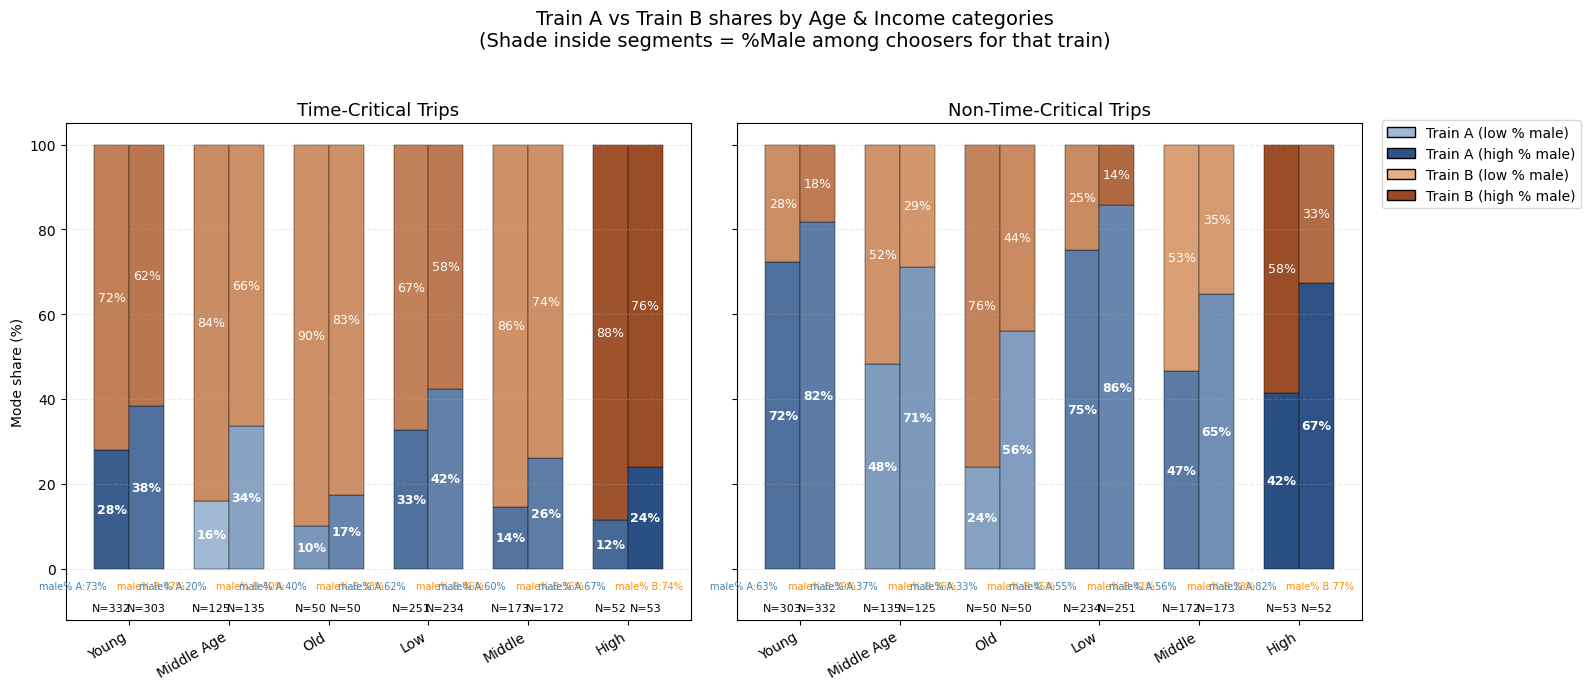

In [31]:
# ---------------------------
# SP CHOICE: AGE+INCOME CATEGORIES
# Two side-by-side plots: Time-Critical | Non-Time-Critical
# Each category -> pair of bars (STR, BER), stacked Train A / Train B.
# The shade inside each stacked segment encodes %Male among choosers for that train.
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import os

# ---------------------------
# Utility: color interpolation
# ---------------------------
def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(
        int(np.clip(rgb[0],0,1)*255),
        int(np.clip(rgb[1],0,1)*255),
        int(np.clip(rgb[2],0,1)*255)
    )

def interp_hex(color_light_hex, color_dark_hex, t):
    """Interpolate between light and dark hex colors by fraction t in [0,1]."""
    # if t is nan, fallback to 0.5
    if t is None or (isinstance(t, float) and np.isnan(t)):
        t = 0.5
    t = float(np.clip(t, 0.0, 1.0))
    light = np.array(hex_to_rgb(color_light_hex))
    dark  = np.array(hex_to_rgb(color_dark_hex))
    rgb = light + (dark - light) * t
    return rgb_to_hex(tuple(rgb))

# ---------------------------
# Load data
# ---------------------------

df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/final_SP_Choice_Graph.csv')


# ---------------------------
# Expected columns (one-hot and choices)
# ---------------------------
# Age and Income categories on X-axis:
age_cols = ['Age_Young', 'Age_Middle_Age', 'Age_Old']
income_cols = ['Income_Low', 'Income_Middle', 'Income_High']

# Gender one-hot for computing %Male:
gender_male_col = 'Gender_Male'
gender_female_col = 'Gender_Female'

# Routes and trip purpose:
route_STR_col = 'STR'
route_BER_col = 'BER'
trip_timecrit = 'TripPurpose_Time_Critical'
trip_non_timecrit = 'TripPurpose_Non_Time_Critical'

# Choice indicators:
choice_A_col = 'Choice_ZugA'
choice_B_col = 'Choice_ZugB'

# Validate presence
required = age_cols + income_cols + [gender_male_col, gender_female_col,
                                     route_STR_col, route_BER_col,
                                     trip_timecrit, trip_non_timecrit,
                                     choice_A_col, choice_B_col]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# Convert to binary (safety)
for c in required:
    df[c] = (df[c] > 0).astype(int)

# ---------------------------
# Build category order and labels
# ---------------------------
categories = []
category_labels = []
# Age first, then Income (as requested)
for c in age_cols + income_cols:
    categories.append(c)
    # human friendly label
    label = c.replace('_', ' ').replace('Age ', '').replace('Income ', '')
    category_labels.append(label)

n_cats = len(categories)

# ---------------------------
# Color config for gradients
# ---------------------------
# Train A uses blue scale, Train B uses orange scale
A_light, A_dark = '#c6dbef', '#08306b'   # light blue -> dark blue
B_light, B_dark = '#fdd0a2', '#7f2704'   # light orange -> dark orange

# Also base colors for edge or fallback
A_base = '#2b83ba'
B_base = '#ff7f0e'

# ---------------------------
# Helper to compute metrics per (trip, route, category)
# ---------------------------
def compute_metrics_for(trip_col, route_col, category_col):
    """
    For a given trip purpose (filter), route (STR/BER), and one-hot category, compute:
      - n_rows: number of observations in subgroup
      - count_A, count_B
      - share_A_pct, share_B_pct  (A + B normalized to 100)
      - male_pct_A (male% among those who chose A in that subgroup) [0..1]
      - male_pct_B (male% among those who chose B in that subgroup) [0..1]
      - fallback_male_pct (male% among all in the category & route & trip), used if no choosers for a train
    """
    sel = df[(df[trip_col] == 1) & (df[route_col] == 1) & (df[category_col] == 1)]
    n = len(sel)
    count_A = int(sel[choice_A_col].sum())
    count_B = int(sel[choice_B_col].sum())
    total_choice_counts = count_A + count_B

    if total_choice_counts > 0:
        share_A = 100.0 * count_A / total_choice_counts
        share_B = 100.0 * count_B / total_choice_counts
    else:
        share_A = np.nan
        share_B = np.nan

    # male percentages among choosers for A and B
    male_A = None
    male_B = None

    if count_A > 0:
        sel_A = sel[ sel[choice_A_col] == 1 ]
        male_A = (sel_A[gender_male_col].sum() / len(sel_A)) if len(sel_A) > 0 else None
    if count_B > 0:
        sel_B = sel[ sel[choice_B_col] == 1 ]
        male_B = (sel_B[gender_male_col].sum() / len(sel_B)) if len(sel_B) > 0 else None

    # fallback: male fraction among category (all respondents in subgroup)
    fallback_male = (sel[gender_male_col].sum() / n) if n > 0 else np.nan

    # If male_A or male_B is None, use fallback (if fallback is nan too, set 0.5)
    if male_A is None:
        male_A = fallback_male if (not np.isnan(fallback_male)) else 0.5
    if male_B is None:
        male_B = fallback_male if (not np.isnan(fallback_male)) else 0.5

    return {
        'n': n,
        'count_A': count_A,
        'count_B': count_B,
        'share_A': share_A,
        'share_B': share_B,
        'male_pct_A': male_A,
        'male_pct_B': male_B,
        'fallback_male': fallback_male
    }

# ---------------------------
# Build metric tables for both trip purposes
# ---------------------------
def build_table_for_trip(trip_col):
    """
    Returns list of rows in the same order as categories,
    each row containing metrics for STR and BER.
    """
    rows = []
    for cat in categories:
        metrics_STR = compute_metrics_for(trip_col, route_STR_col, cat)
        metrics_BER = compute_metrics_for(trip_col, route_BER_col, cat)
        rows.append({'category': cat, 'label': cat.replace('_',' ').replace('Age ','').replace('Income ',''),
                     'STR': metrics_STR, 'BER': metrics_BER})
    return rows

table_timecrit = build_table_for_trip(trip_timecrit)
table_nontime = build_table_for_trip(trip_non_timecrit)

# ---------------------------
# Plotting function
# ---------------------------
def plot_two_side_by_side(table_left, table_right, left_title, right_title, savefile=None):
    fig, axes = plt.subplots(1,2, figsize=(16,7), sharey=True)
    for ax, table, title in zip(axes, [table_left, table_right], [left_title, right_title]):
        x = np.arange(len(table))
        bar_width = 0.35

        # For each category index, we will place STR at x - offset and BER at x + offset
        for idx, rec in enumerate(table):
            # STR bar
            mSTR = rec['STR']
            mBER = rec['BER']

            # If both shares are NaN (no A+B choices), we will skip drawing stacked segments (draw empty outline)
            # Prepare values (use 0 when NaN for drawing)
            a_STR = 0.0 if np.isnan(mSTR['share_A']) else mSTR['share_A']
            b_STR = 0.0 if np.isnan(mSTR['share_B']) else mSTR['share_B']
            a_BER = 0.0 if np.isnan(mBER['share_A']) else mBER['share_A']
            b_BER = 0.0 if np.isnan(mBER['share_B']) else mBER['share_B']

            # Colors for segments, interpolate based on male pct
            color_A_STR = interp_hex(A_light, A_dark, mSTR['male_pct_A'])
            color_B_STR = interp_hex(B_light, B_dark, mSTR['male_pct_B'])
            color_A_BER = interp_hex(A_light, A_dark, mBER['male_pct_A'])
            color_B_BER = interp_hex(B_light, B_dark, mBER['male_pct_B'])

            # Positions
            x_STR = idx - bar_width/2
            x_BER = idx + bar_width/2

            # DRAW STR stacked bar (A then B on top)
            bottom = 0.0
            if a_STR > 0:
                ax.bar(x_STR, a_STR, bar_width, bottom=bottom, color=color_A_STR, edgecolor='k', linewidth=0.3)
                bottom += a_STR
            if b_STR > 0:
                ax.bar(x_STR, b_STR, bar_width, bottom=bottom, color=color_B_STR, edgecolor='k', linewidth=0.3)
                bottom += b_STR

            # If both zero and there were N rows, draw thin outline to show presence
            if (a_STR == 0 and b_STR == 0) and mSTR['n'] > 0:
                ax.bar(x_STR, 100, bar_width, bottom=0, fill=False, edgecolor='lightgray', hatch='//', linewidth=0.5)

            # DRAW BER stacked bar
            bottom = 0.0
            if a_BER > 0:
                ax.bar(x_BER, a_BER, bar_width, bottom=bottom, color=color_A_BER, edgecolor='k', linewidth=0.3)
                bottom += a_BER
            if b_BER > 0:
                ax.bar(x_BER, b_BER, bar_width, bottom=bottom, color=color_B_BER, edgecolor='k', linewidth=0.3)
                bottom += b_BER
            if (a_BER == 0 and b_BER == 0) and mBER['n'] > 0:
                ax.bar(x_BER, 100, bar_width, bottom=0, fill=False, edgecolor='lightgray', hatch='..', linewidth=0.5)

            # Annotate percentages on the segments (if present)
            # STR
            if a_STR > 0:
                ax.text(x_STR, a_STR/2, f"{a_STR:.0f}%", ha='center', va='center', color='white', fontsize=9, fontweight='bold')
            if b_STR > 0:
                ax.text(x_STR, (a_STR + b_STR/2), f"{b_STR:.0f}%", ha='center', va='center', color='white', fontsize=9)

            # BER
            if a_BER > 0:
                ax.text(x_BER, a_BER/2, f"{a_BER:.0f}%", ha='center', va='center', color='white', fontsize=9, fontweight='bold')
            if b_BER > 0:
                ax.text(x_BER, (a_BER + b_BER/2), f"{b_BER:.0f}%", ha='center', va='center', color='white', fontsize=9)

            # Annotate sample sizes under each bar
            ax.text(x_STR, -8, f"N={mSTR['n']}", ha='center', va='top', fontsize=8, color='black')
            ax.text(x_BER, -8, f"N={mBER['n']}", ha='center', va='top', fontsize=8, color='black')

            # Optionally annotate male% (small) on top corner of each segment
            # STR male percent for A and B
            ax.text(x_STR - 0.05, -4, f"male% A:{(mSTR['male_pct_A']*100):.0f}%", ha='right', va='center', fontsize=7, color='steelblue')
            ax.text(x_STR + 0.05, -4, f"male% B:{(mSTR['male_pct_B']*100):.0f}%", ha='left', va='center', fontsize=7, color='darkorange')

        # Aesthetics for this axis
        ax.set_xticks(np.arange(len(table)))
        ax.set_xticklabels([r['label'] for r in table], rotation=30, ha='right')
        ax.set_ylim(-12, 105)
        ax.set_title(title, fontsize=13)
        ax.set_ylabel("Mode share (%)" if ax is axes[0] else "")
        ax.grid(axis='y', linestyle='--', alpha=0.25)

    # Legend (create custom legend for Train A/B color families)
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor=interp_hex(A_light, A_dark, 0.2), edgecolor='k', label='Train A (low % male)'),
        Patch(facecolor=interp_hex(A_light, A_dark, 0.8), edgecolor='k', label='Train A (high % male)'),
        Patch(facecolor=interp_hex(B_light, B_dark, 0.2), edgecolor='k', label='Train B (low % male)'),
        Patch(facecolor=interp_hex(B_light, B_dark, 0.8), edgecolor='k', label='Train B (high % male)')
    ]
    axes[1].legend(handles=legend_elems, bbox_to_anchor=(1.02, 1.02))

    plt.suptitle("Train A vs Train B shares by Age & Income categories\n(Shade inside segments = %Male among choosers for that train)", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.95])
    if savefile:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()

# ---------------------------
# Run the plotting
# ---------------------------
plot_two_side_by_side(table_timecrit, table_nontime,
                      left_title="Time-Critical Trips", right_title="Non-Time-Critical Trips",
                      savefile="SP_choice_AgeIncome_byTripPurpose.png")


In [ ]:
df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/final_SP_Choice_Graph.csv')

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load data
df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Choice/final_SP_Choice_Graph.csv')

# Define sociodemographic variables and their categories
socio_variables = {
    'Age': ['Age_Young', 'Age_Middle_Age', 'Age_Old'],
    'Income': ['Income_Low', 'Income_Middle', 'Income_High'],
    'Gender': ['Gender_Female', 'Gender_Male', 'Gender_Other']
}

trip_purpose_filter = {
    'Time Critical': 'TripPurpose_Time_Critical',
    'Non-Time Critical': 'TripPurpose_Non_Time_Critical'
}

routes = ['STR', 'BER']
route_colors = {'STR': '#FF6B6B', 'BER': '#4ECDC4'}  # Different colors for routes
train_colors = {'A': '#F5B041', 'B': '#5DADE2'}  # Train A and B colors


def create_comparison_figure(df, variable_name, variable_columns):
    """
    Create a side-by-side comparison figure for Time-Critical and Non-Time-Critical trips
    for a given sociodemographic variable.
    
    Parameters:
    - variable_name: Name of the sociodemographic variable (e.g., 'Age')
    - variable_columns: List of binary-encoded columns for this variable
    """
    
    # Create figure with 2 subplots (Time-Critical, Non-Time-Critical)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f'Mode Share by {variable_name}, Trip Purpose, and Route\n(Stated Preference Survey)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Process each trip purpose
    for ax_idx, (trip_name, trip_filter_col) in enumerate(trip_purpose_filter.items()):
        ax = axes[ax_idx]
        
        # Filter data by trip purpose
        trip_filtered_df = df[df[trip_filter_col] == 1].copy()
        
        if len(trip_filtered_df) == 0:
            ax.text(0.5, 0.5, f'No data for {trip_name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            continue
        
        # Prepare data for plotting
        plot_data = []
        x_positions = []
        x_labels = []
        x_pos = 0
        
        # Iterate through each category of the variable
        for cat_idx, col in enumerate(variable_columns):
            category_name = col.replace(f'{variable_name}_', '').replace('_', ' ')
            
            # Filter by category
            cat_filtered_df = trip_filtered_df[trip_filtered_df[col] == 1]
            
            if len(cat_filtered_df) == 0:
                continue
            
            # Iterate through routes (STR and BER)
            for route_idx, route in enumerate(routes):
                route_data = cat_filtered_df[cat_filtered_df[route] == 1]
                
                if len(route_data) > 0:
                    total = len(route_data)
                    zug_a_share = (route_data['Choice_ZugA'].sum() / total) * 100
                    zug_b_share = (route_data['Choice_ZugB'].sum() / total) * 100
                    
                    plot_data.append({
                        'Category': category_name,
                        'Route': route,
                        'Train_A': zug_a_share,
                        'Train_B': zug_b_share,
                        'Total': total,
                        'x_pos': x_pos
                    })
                    
                    x_positions.append(x_pos)
                    x_labels.append(f"{category_name}\n({route})")
                    x_pos += 1
            
            x_pos += 0.5  # Add gap between categories
        
        # Plot stacked bars
        plot_df = pd.DataFrame(plot_data)
        
        bar_width = 0.6
        
        # Create stacked bars
        bars1 = ax.bar(plot_df['x_pos'], plot_df['Train_A'], bar_width,
                       label='Train A', color=train_colors['A'], alpha=0.85, 
                       edgecolor='black', linewidth=1.5)
        
        bars2 = ax.bar(plot_df['x_pos'], plot_df['Train_B'], bar_width,
                       bottom=plot_df['Train_A'],
                       label='Train B', color=train_colors['B'], alpha=0.85,
                       edgecolor='black', linewidth=1.5)
        
        # Add percentage labels and sample size
        for idx, row in plot_df.iterrows():
            x = row['x_pos']
            
            # Train A percentage
            if row['Train_A'] > 5:
                ax.text(x, row['Train_A'] / 2, f"{row['Train_A']:.0f}%",
                       ha='center', va='center', fontweight='bold', fontsize=9, color='white')
            
            # Train B percentage
            if row['Train_B'] > 5:
                ax.text(x, row['Train_A'] + row['Train_B'] / 2, f"{row['Train_B']:.0f}%",
                       ha='center', va='center', fontweight='bold', fontsize=9, color='white')
            
            # Sample size below bar
            ax.text(x, -8, f"n={int(row['Total'])}", ha='center', va='top', 
                   fontsize=8, style='italic', color='gray')
        
        # Formatting
        ax.set_xticks(plot_df['x_pos'])
        ax.set_xticklabels(x_labels, fontsize=10, rotation=45, ha='right')
        ax.set_ylabel('Mode Share (%)', fontsize=12, fontweight='bold')
        ax.set_ylim(-15, 110)
        ax.set_title(f'{trip_name} Trips', fontsize=13, fontweight='bold', pad=10)
        
        # Add reference line at 50%
        ax.axhline(y=50, color='gray', linestyle='--', linewidth=1.5, alpha=0.4, label='Equal Share')
        
        # Grid
        ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)
        
        # Legend (only on first subplot)
        if ax_idx == 0:
            ax.legend(loc='upper right', fontsize=11, framealpha=0.95)
    
    plt.tight_layout()
    return fig


# Generate figures for each sociodemographic variable
for var_name, var_columns in socio_variables.items():
    fig = create_comparison_figure(df, var_name, var_columns)
    
    save_path = f'/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/comparison_{var_name.lower()}.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Figure saved: {save_path}")
    plt.close()

print("\n✓ All figures generated successfully!")


✓ Figure saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/comparison_age.png
✓ Figure saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/comparison_income.png
✓ Figure saved: /Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/comparison_gender.png

✓ All figures generated successfully!


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define sociodemographic variables and their categories
socio_variables = {
    'Age': ['Age_Young', 'Age_Middle_Age', 'Age_Old'],
    'Income': ['Income_Low', 'Income_Middle', 'Income_High'],
    'Gender': ['Gender_Female', 'Gender_Male', 'Gender_Other']
}

trip_purpose_filter = {
    'Time Critical': 'TripPurpose_Time_Critical',
    'Non-Time Critical': 'TripPurpose_Non_Time_Critical'
}

routes = ['STR', 'BER']


def extract_and_tabulate_data(df, variable_name, variable_columns):
    """
    Extract data from graphs and generate both LaTeX tables and a summary DataFrame
    
    Parameters:
    - variable_name: Name of the sociodemographic variable (e.g., 'Age')
    - variable_columns: List of binary-encoded columns for this variable
    
    Returns:
    - summary_df: DataFrame with all extracted data
    - latex_table: LaTeX formatted table string
    """
    
    # Collect all data
    all_data = []
    
    # Process each trip purpose
    for trip_name, trip_filter_col in trip_purpose_filter.items():
        trip_filtered_df = df[df[trip_filter_col] == 1].copy()
        
        # Iterate through each category of the variable
        for col in variable_columns:
            category_name = col.replace(f'{variable_name}_', '').replace('_', ' ')
            cat_filtered_df = trip_filtered_df[trip_filtered_df[col] == 1]
            
            if len(cat_filtered_df) == 0:
                continue
            
            # Iterate through routes
            for route in routes:
                route_data = cat_filtered_df[cat_filtered_df[route] == 1]
                
                if len(route_data) > 0:
                    total = len(route_data)
                    zug_a_share = (route_data['Choice_ZugA'].sum() / total) * 100
                    zug_b_share = (route_data['Choice_ZugB'].sum() / total) * 100
                    
                    all_data.append({
                        'Trip Purpose': trip_name,
                        'Category': category_name,
                        'Route': route,
                        'Train A (%)': round(zug_a_share, 2),
                        'Train B (%)': round(zug_b_share, 2),
                        'Sample Size': total
                    })
    
    # Create DataFrame
    summary_df = pd.DataFrame(all_data)
    
    # Generate LaTeX table
    latex_table = generate_latex_table(summary_df, variable_name)
    
    return summary_df, latex_table


def generate_latex_table(df, variable_name):
    """
    Generate a professional LaTeX table from the extracted data
    """
    
    latex_str = f"""\\begin{{table}}[!h]
\\centering
\\caption{{Mode Share by {variable_name}, Trip Purpose, and Route}}
\\label{{tab:{variable_name.lower()}_mode_share}}
\\begin{{tabular}}{{lllrrrr}}
\\toprule
Trip Purpose & {variable_name} & Route & Train A (\\%) & Train B (\\%) & Sample Size \\\\
\\midrule
"""
    
    # Group by trip purpose for readability
    for trip_purpose in df['Trip Purpose'].unique():
        trip_data = df[df['Trip Purpose'] == trip_purpose]
        
        for idx, (_, row) in enumerate(trip_data.iterrows()):
            # Add trip purpose label only for first row of each group
            if idx == 0:
                trip_label = row['Trip Purpose']
            else:
                trip_label = ''
            
            latex_str += f"{trip_label} & {row['Category']} & {row['Route']} & {row['Train A (%)']:.2f} & {row['Train B (%)']:.2f} & {int(row['Sample Size'])} \\\\\n"
        
        # Add horizontal line between trip purposes
        if trip_purpose != df['Trip Purpose'].unique()[-1]:
            latex_str += "\\midrule\n"
    
    latex_str += """\\bottomrule
\\end{tabular}
\\end{table}
"""
    
    return latex_str


def generate_comprehensive_latex_report(df, variable_name, variable_columns):
    """
    Generate a comprehensive LaTeX table with summary statistics
    """
    
    summary_df, latex_table = extract_and_tabulate_data(df, variable_name, variable_columns)
    
    # Calculate additional statistics for each category
    stats_data = []
    
    for trip_purpose in trip_purpose_filter.keys():
        trip_data = summary_df[summary_df['Trip Purpose'] == trip_purpose]
        
        for category in trip_data['Category'].unique():
            cat_data = trip_data[trip_data['Category'] == category]
            
            # Average Train A preference across routes
            avg_train_a = cat_data['Train A (%)'].mean()
            total_n = cat_data['Sample Size'].sum()
            
            stats_data.append({
                'Trip Purpose': trip_purpose,
                'Category': category,
                'Avg Train A (%)': round(avg_train_a, 2),
                'Total Sample': int(total_n)
            })
    
    stats_df = pd.DataFrame(stats_data)
    
    # Generate summary LaTeX table
    summary_latex = f"""\\begin{{table}}[!h]
\\centering
\\caption{{Summary: Mode Share by {variable_name} and Trip Purpose}}
\\label{{tab:{variable_name.lower()}_summary}}
\\begin{{tabular}}{{lrr}}
\\toprule
{variable_name} & Trip Purpose & Avg Train A (\\%) \\\\
\\midrule
"""
    
    for _, row in stats_df.iterrows():
        summary_latex += f"{row['Category']} & {row['Trip Purpose']} & {row['Avg Train A (%)']:.2f} \\\\\n"
    
    summary_latex += """\\bottomrule
\\end{tabular}
\\end{table}
"""
    
    return summary_df, latex_table, summary_latex


# Process all sociodemographic variables and generate tables
all_summaries = {}
latex_output = {}

for var_name, var_columns in socio_variables.items():
    print(f"\n{'='*60}")
    print(f"Processing: {var_name}")
    print(f"{'='*60}")
    
    # Extract data and generate LaTeX tables
    summary_df, main_latex, summary_latex = generate_comprehensive_latex_report(
        df, var_name, var_columns
    )
    
    all_summaries[var_name] = summary_df
    latex_output[var_name] = {
        'main_table': main_latex,
        'summary_table': summary_latex
    }
    
    # Save LaTeX tables to files
    with open(f'table_{var_name.lower()}_detailed.tex', 'w') as f:
        f.write(main_latex)
    
    with open(f'table_{var_name.lower()}_summary.tex', 'w') as f:
        f.write(summary_latex)
    
    # Print summary to console
    print(f"\nData Summary for {var_name}:")
    print(summary_df.to_string(index=False))
    print(f"\n✓ LaTeX table saved: table_{var_name.lower()}_detailed.tex")
    print(f"✓ LaTeX summary saved: table_{var_name.lower()}_summary.tex")


# Generate a combined LaTeX document with all tables (optional)
combined_latex = """\\documentclass{article}
\\usepackage{booktabs}
\\usepackage{table}

\\begin{document}

\\section{Mode Share Analysis by Sociodemographic Characteristics}

"""

for var_name in socio_variables.keys():
    combined_latex += latex_output[var_name]['detailed_table'] + "\n\n"
    combined_latex += latex_output[var_name]['summary_table'] + "\n\n"

combined_latex += """\\end{document}
"""

with open('all_mode_share_tables.tex', 'w') as f:
    f.write(combined_latex)

print("\n" + "="*60)
print("✓ All tables generated successfully!")
print("="*60)
print("\nGenerated files:")
print("  - table_age_detailed.tex")
print("  - table_age_summary.tex")
print("  - table_income_detailed.tex")
print("  - table_income_summary.tex")
print("  - table_gender_detailed.tex")
print("  - table_gender_summary.tex")
print("  - all_mode_share_tables.tex (combined document)")



Processing: Age

Data Summary for Age:
     Trip Purpose   Category Route  Train A (%)  Train B (%)  Sample Size
    Time Critical      Young   STR        28.01        71.99          332
    Time Critical      Young   BER        35.31        56.77          303
    Time Critical Middle Age   STR        16.00        84.00          125
    Time Critical Middle Age   BER        29.63        58.52          135
    Time Critical        Old   STR        10.00        90.00           50
    Time Critical        Old   BER        16.00        76.00           50
Non-Time Critical      Young   STR        72.28        27.72          303
Non-Time Critical      Young   BER        81.63        18.37          332
Non-Time Critical Middle Age   STR        48.15        51.85          135
Non-Time Critical Middle Age   BER        71.20        28.80          125
Non-Time Critical        Old   STR        24.00        76.00           50
Non-Time Critical        Old   BER        56.00        44.00           5

KeyError: 'detailed_table'

/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_6196/1412847035.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(x[xi]+offset, a_vals[xi]/2, f"{a_vals[xi]:.0f}%", ha='center', va='center', color='white', fontsize=8)
/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_6196/1412847035.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(x[xi]+offset, a_vals[xi]+b_vals[xi]/2, f"{b_vals[xi]:.0f}%", ha='center', va='center', color='white', fontsize=8)
/var/folders/w5/qh29ykzx453d3183093yqjlw0000gn/T/ipykernel_6196/1412847035.py:68: FutureWarning: Series.__getitem__ treating keys as po

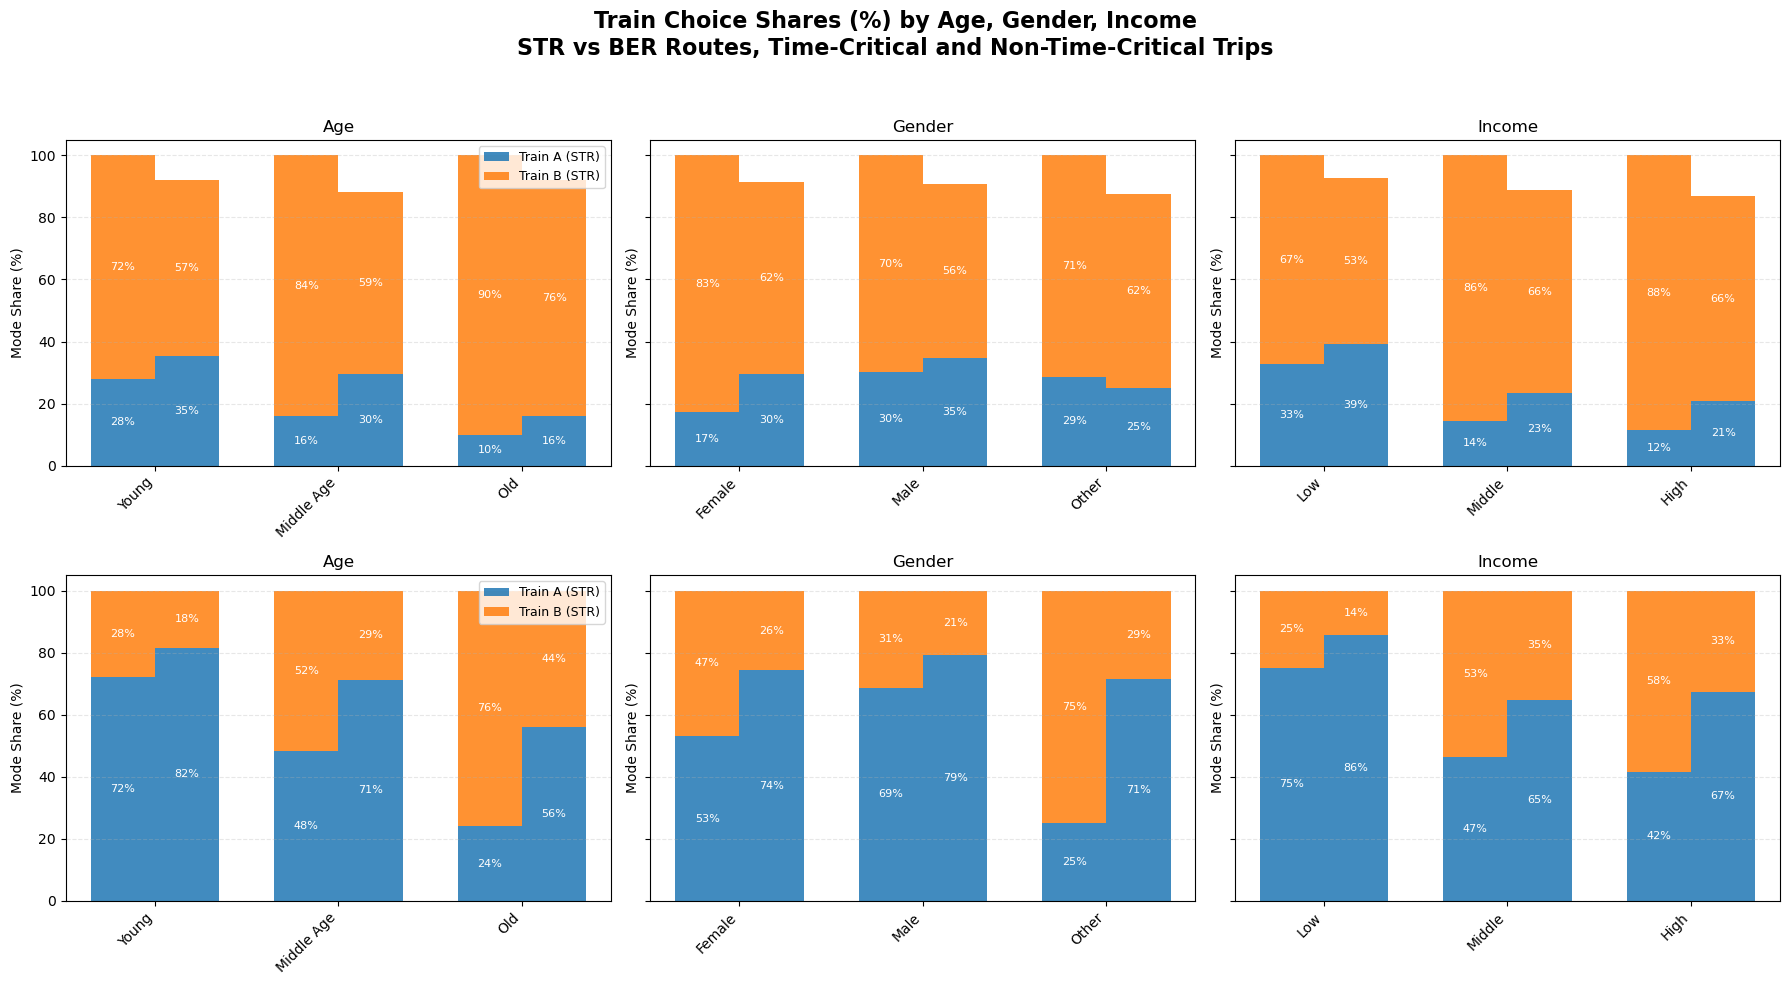

✅ Combined SP Choice Figure with all categories generated successfully.


In [45]:
# ============================================================
# SP CHOICE PLOTS BY AGE, GENDER, INCOME — SIDE-BY-SIDE FIGURES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Define relevant columns ---
choice_cols = ['Choice_ZugA', 'Choice_ZugB']
route_cols = ['STR', 'BER']
trip_cols = ['TripPurpose_Time_Critical', 'TripPurpose_Non_Time_Critical']
category_groups = {
    "Age": ['Age_Young', 'Age_Middle_Age', 'Age_Old'],
    "Gender": ['Gender_Female', 'Gender_Male', 'Gender_Other'],
    "Income": ['Income_Low', 'Income_Middle', 'Income_High']
}

# --- Ensure binary format ---
for c in choice_cols + route_cols + trip_cols + sum(category_groups.values(), []):
    if c not in df.columns:
        raise ValueError(f"Missing expected column: {c}")
    df[c] = (df[c] > 0).astype(int)

# --- Function to compute Train shares ---
def compute_shares(df, cat_cols, route_col, trip_col):
    records = []
    for cat in cat_cols:
        subset = df[(df[route_col]==1) & (df[trip_col]==1) & (df[cat]==1)]
        n = len(subset)
        if n == 0:
            continue
        a_share = 100*subset['Choice_ZugA'].sum()/n
        b_share = 100*subset['Choice_ZugB'].sum()/n
        records.append({'Category': cat.replace('_',' '), 'Train':'Train A', 'Share': a_share, 'Route': route_col})
        records.append({'Category': cat.replace('_',' '), 'Train':'Train B', 'Share': b_share, 'Route': route_col})
    return pd.DataFrame(records)

# --- Prepare summary dataframe ---
summary_list = []
for trip_col in trip_cols:
    for group_name, cat_cols in category_groups.items():
        for route in route_cols:
            df_temp = compute_shares(df, cat_cols, route, trip_col)
            df_temp['Variable'] = group_name
            df_temp['Trip'] = trip_col
            summary_list.append(df_temp)

summary_df = pd.concat(summary_list, ignore_index=True)

# --- Function to plot one category subplot ---
def plot_category_subplot(ax, df_cat, variable_name):
    categories = df_cat['Category'].unique()
    x = np.arange(len(categories))
    bar_width = 0.35
    colors = ['#1f77b4','#ff7f0e']  # Train A, Train B
    
    for i, route in enumerate(['STR','BER']):
        df_route = df_cat[df_cat['Route']==route].pivot(index='Category', columns='Train', values='Share').fillna(0)
        a_vals = df_route['Train A'].reindex(categories, fill_value=0)
        b_vals = df_route['Train B'].reindex(categories, fill_value=0)
        offset = (-0.5 if route=='STR' else 0.5)*bar_width
        ax.bar(x+offset, a_vals, bar_width, color=colors[0], label=f'Train A ({route})' if i==0 else "", alpha=0.85)
        ax.bar(x+offset, b_vals, bar_width, bottom=a_vals, color=colors[1], label=f'Train B ({route})' if i==0 else "", alpha=0.85)
        
        # Annotate percentages
        for xi, cat in enumerate(categories):
            ax.text(x[xi]+offset, a_vals[xi]/2, f"{a_vals[xi]:.0f}%", ha='center', va='center', color='white', fontsize=8)
            ax.text(x[xi]+offset, a_vals[xi]+b_vals[xi]/2, f"{b_vals[xi]:.0f}%", ha='center', va='center', color='white', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace(variable_name+" ","") for c in categories], rotation=45, ha='right')
    ax.set_ylabel("Mode Share (%)")
    ax.set_title(variable_name, fontsize=12)
    ax.set_ylim(0,105)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# --- Plotting Time-Critical and Non-Time-Critical side by side ---
fig, axes = plt.subplots(2, 3, figsize=(18,10), sharey=True)

trip_mapping = {'TripPurpose_Time_Critical':'Time-Critical','TripPurpose_Non_Time_Critical':'Non-Time-Critical'}

for row, trip_col in enumerate(trip_cols):
    for col, (variable_name, cat_cols) in enumerate(category_groups.items()):
        df_cat = summary_df[(summary_df['Trip']==trip_col) & (summary_df['Variable']==variable_name)]
        plot_category_subplot(axes[row,col], df_cat, variable_name)
        
axes[0,0].set_title("Age", fontsize=12)
axes[0,1].set_title("Gender", fontsize=12)
axes[0,2].set_title("Income", fontsize=12)
axes[0,0].legend(loc='upper right', fontsize=9)
axes[1,0].legend(loc='upper right', fontsize=9)

# Add overall figure title
plt.suptitle("Train Choice Shares (%) by Age, Gender, Income\nSTR vs BER Routes, Time-Critical and Non-Time-Critical Trips", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig("SP_Choice_AllCategories_TimeCritical_vs_NonTimeCritical.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Combined SP Choice Figure with all categories generated successfully.")


In [147]:
# Define delay types and routes
delay_types = ['delay_HL', 'delay_HS', 'delay_LL', 'delay_LS']
routes = ['STR', 'BER']

# Recreate mode_share dictionary
mode_share = {route: {} for route in routes}

for route in routes:
    for delay in delay_types:
        mask = (df[route] == 1) & (df[delay] == 1)
        subset = df[mask]
        total = len(subset)
        if total > 0:
            share_a = subset['Choice_ZugA'].sum() / total
            share_b = subset['Choice_ZugB'].sum() / total
            mode_share[route][delay] = [share_a, share_b]
        else:
            mode_share[route][delay] = [float('nan'), float('nan')]

print(mode_share)

{'STR': {'delay_HL': [1.0, 0.0], 'delay_HS': [0.45714285714285713, 0.5428571428571428], 'delay_LL': [0.4337899543378995, 0.5662100456621004], 'delay_LS': [0.0, 1.0]}, 'BER': {'delay_HL': [1.0, 0.0], 'delay_HS': [0.5862068965517241, 0.41379310344827586], 'delay_LL': [0.6534653465346535, 0.3465346534653465], 'delay_LS': [0.0, 1.0]}}


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ===================== USER CONFIG (edit here) =====================
CSV_PATH = '/Users/syed/Downloads/Applications/Companies/Thesis/Coding/Data/final_biogeme_Data_200.csv'

# Choice columns (assumed from your code)
COL_CHOICE_A = 'Choice_ZugA'
COL_CHOICE_B = 'Choice_ZugB'   # not needed for %A, but kept for completeness

# Route flags used earlier (1 if that route)
ROUTE_COLS = {'STR': 'STR', 'BER': 'BER'}

# Trip purpose flags (1 if that purpose)
TRIP_PURPOSE_COLS = {'Time Critical': 'TripPurpose_Time_Critical',
                     'Non-Time Critical': 'TripPurpose_Non_Time_Critical'}

# Sociodemographic one-hot groups (as in your code)
SOCIO_GROUPS = {
    'Age': ['Age_Young', 'Age_Middle_Age', 'Age_Old'],
    'Income': ['Income_Low', 'Income_Middle', 'Income_High'],
    'Gender': ['Gender_Female', 'Gender_Male', 'Gender_Other']
}

# Reliability encoding – tell the code what you have.
# Option A: a single "Case" column (values 1..5 as defined in your design)
CASE_COL = 'Case'      # set to None if you don't have it

# Option B: direct label columns like 'A_rel','B_rel' with values in {'HL','HS','LL','LS'}
A_REL_COL = None       # e.g., 'A_rel'
B_REL_COL = None       # e.g., 'B_rel'

# Option C: one-hot reliability flags for each train (True/1 if that level)
A_REL_FLAGS = {'HL': 'A_HL', 'HS': 'A_HS', 'LL': 'A_LL', 'LS': 'A_LS'}  # set to None if unused
B_REL_FLAGS = {'HL': 'B_HL', 'HS': 'B_HS', 'LL': 'B_LL', 'LS': 'B_LS'}  # set to None if unused

# Where to save the figures
SAVE_DIR = Path('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/heatmaps')
SAVE_DIR.mkdir(parents=True, exist_ok=True)
# ===================================================================

# Mapping from Case -> (A_rel, B_rel) per your SP design
CASE_TO_PAIR = {
    1: ('HL', 'HS'),
    2: ('HL', 'LL'),
    3: ('HL', 'LS'),
    4: ('HS', 'LS'),
    5: ('LL', 'LS')
}
VALID_LEVELS = ['HL', 'HS', 'LL', 'LS']  # order for axes

def derive_rel_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has columns 'A_rel_lbl' and 'B_rel_lbl' in {HL,HS,LL,LS}.
    Supports three input styles: CASE, direct label cols, or one-hot flags.
    """
    out = df.copy()

    if CASE_COL and CASE_COL in out.columns:
        pairs = out[CASE_COL].map(CASE_TO_PAIR)
        out['A_rel_lbl'] = pairs.str[0]
        out['B_rel_lbl'] = pairs.str[1]
    elif A_REL_COL and B_REL_COL and A_REL_COL in out.columns and B_REL_COL in out.columns:
        out['A_rel_lbl'] = out[A_REL_COL]
        out['B_rel_lbl'] = out[B_REL_COL]
    elif A_REL_FLAGS and B_REL_FLAGS and all(c in out.columns for c in A_REL_FLAGS.values()) and all(c in out.columns for c in B_REL_FLAGS.values()):
        def _flag_to_lbl(row, mapping):
            for lbl, col in mapping.items():
                if row.get(col, 0) == 1:
                    return lbl
            return np.nan
        out['A_rel_lbl'] = out.apply(_flag_to_lbl, axis=1, mapping=A_REL_FLAGS)
        out['B_rel_lbl'] = out.apply(_flag_to_lbl, axis=1, mapping=B_REL_FLAGS)
    else:
        raise ValueError("Could not derive reliability labels. "
                         "Set up CASE_COL or A_REL/B_REL or A_REL_FLAGS/B_REL_FLAGS correctly.")
    return out

def filter_block(df, route_key=None, trip_key=None, socio_col=None):
    """
    Apply Route, Trip Purpose, and optional sociodemographic one-hot filter.
    """
    mask = pd.Series(True, index=df.index)

    if route_key is not None:
        route_col = ROUTE_COLS[route_key]
        mask &= (df[route_col] == 1)

    if trip_key is not None:
        trip_col = TRIP_PURPOSE_COLS[trip_key]
        mask &= (df[trip_col] == 1)

    if socio_col is not None:
        mask &= (df[socio_col] == 1)

    return df[mask].copy()

def heatmap_data(df):
    """
    Build pivot table (% choosing Train A) and a matching count table (n) for annotations.
    """
    if df.empty:
        # Create an empty 4x4 pivot with NaNs
        idx = pd.Index(VALID_LEVELS, name='A_rel_lbl')
        cols = pd.Index(VALID_LEVELS, name='B_rel_lbl')
        return pd.DataFrame(np.nan, index=idx, columns=cols), pd.DataFrame(0, index=idx, columns=cols)

    # Group by observed A/B reliability pair
    g = df.groupby(['A_rel_lbl', 'B_rel_lbl'])
    pctA = 100.0 * (g[COL_CHOICE_A].sum() / g.size())
    n = g.size()

    # Pivot to 4x4 grid (only 5 valid combos will be filled; others = NaN)
    pivot_pctA = pctA.unstack('B_rel_lbl').reindex(index=VALID_LEVELS, columns=VALID_LEVELS)
    pivot_n = n.unstack('B_rel_lbl').reindex(index=VALID_LEVELS, columns=VALID_LEVELS).fillna(0).astype(int)

    return pivot_pctA, pivot_n

def plot_confusion_heatmap(pivot_pctA, pivot_n, title, ax=None, vmin=0, vmax=100, center=50):
    """
    Plot a confusion-matrix-like heatmap (rows=A reliability, cols=B reliability),
    colored by % choosing Train A. Annotate with % and n.
    """
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.5))
        created_ax = True

    sns.heatmap(pivot_pctA, ax=ax, annot=False, cmap='coolwarm', vmin=vmin, vmax=vmax,
                center=center, linewidths=1, linecolor='white', cbar_kws={'label': '% choose Train A'},
                square=True)

    # Annotate each observed cell with "xx% (n=yy)"
    for i, a_lbl in enumerate(pivot_pctA.index):
        for j, b_lbl in enumerate(pivot_pctA.columns):
            val = pivot_pctA.loc[a_lbl, b_lbl]
            n = pivot_n.loc[a_lbl, b_lbl]
            if pd.notnull(val) and n > 0:
                ax.text(j+0.5, i+0.5, f"{val:.0f}%\n(n={n})",
                        ha='center', va='center', fontsize=9, color='black')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Train B reliability")
    ax.set_ylabel("Train A reliability")

    # Light gray hatch for impossible/unseen cells (NaN)
    # Optional: leave as-is; the white grid already shows them.
    if created_ax:
        plt.tight_layout()
        return ax.figure
    return None

def plot_grid_for_group(df, group_name=None, socio_col=None, save=True):
    """
    2x2 grid: rows = Trip Purpose (TC, NTC), cols = Route (STR, BER).
    One heatmap per block.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
    fig.suptitle(f"% choosing Train A by reliability pair (Confusion-Matrix View)\n{group_name or 'All respondents'}",
                 fontsize=14, fontweight='bold', y=0.98)

    for r, route_key in enumerate(['STR', 'BER']):
        for t, trip_key in enumerate(['Time Critical', 'Non-Time Critical']):
            ax = axes[t, r]
            df_block = filter_block(df, route_key=route_key, trip_key=trip_key, socio_col=socio_col)
            pivot_pctA, pivot_n = heatmap_data(df_block)
            title = f"{trip_key} • Route {route_key}"
            plot_confusion_heatmap(pivot_pctA, pivot_n, title=title, ax=ax)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save:
        tag = 'all' if socio_col is None else socio_col
        out = SAVE_DIR / f"confusion_heatmap_{tag}.png"
        fig.savefig(out, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {out}")
    plt.close(fig)

# ===================== RUN =====================
df = pd.read_csv(CSV_PATH)

# 1) Make sure we have A_rel_lbl / B_rel_lbl in {HL,HS,LL,LS}
df = derive_rel_labels(df)

# 2) Safety: ensure choice columns exist
for c in [COL_CHOICE_A, COL_CHOICE_B]:
    if c not in df.columns:
        raise ValueError(f"Missing choice column: {c}")

# 3) Global heatmaps (no socio filter)
plot_grid_for_group(df, group_name="All respondents", socio_col=None, save=True)

# 4) Socio-stratified heatmaps
for group, cols in SOCIO_GROUPS.items():
    for col in cols:
        if col in df.columns:
            plot_grid_for_group(df, group_name=f"{group}: {col.replace(group+'_','').replace('_',' ')}",
                                socio_col=col, save=True)
        else:
            print(f"• Skipped missing column: {col}")
print("✓ Done.")


ValueError: Could not derive reliability labels. Set up CASE_COL or A_REL/B_REL or A_REL_FLAGS/B_REL_FLAGS correctly.

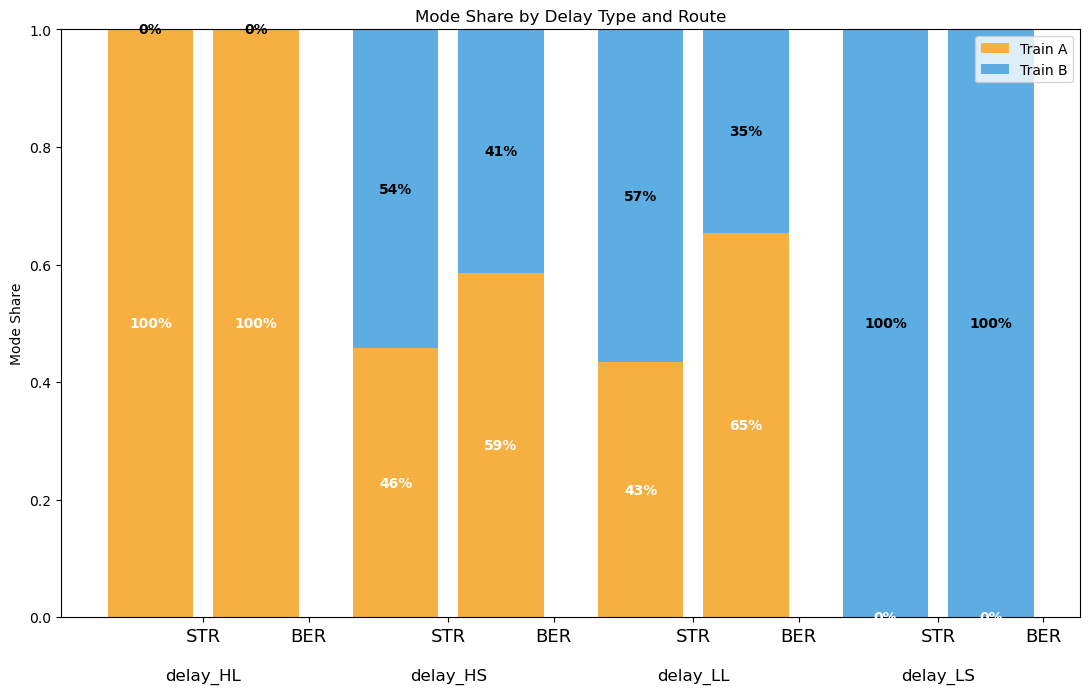

<Figure size 640x480 with 0 Axes>

In [149]:
import matplotlib.pyplot as plt
import numpy as np

# Variables
delay_types = ['delay_HL', 'delay_HS', 'delay_LL', 'delay_LS']
routes = ['STR', 'BER']
route_labels = ['STR', 'BER']

# Prepare data for plotting as before
labels = delay_types
str_shares_a = [mode_share['STR'][d][0] for d in delay_types]
str_shares_b = [mode_share['STR'][d][1] for d in delay_types]
ber_shares_a = [mode_share['BER'][d][0] for d in delay_types]
ber_shares_b = [mode_share['BER'][d][1] for d in delay_types]

bar_width = 0.35
x = np.arange(len(delay_types))

fig, ax = plt.subplots(figsize=(11,7))

# Plot STR bars
rects1 = ax.bar(x, str_shares_a, bar_width, label='Train A', color="#F5B041")
rects2 = ax.bar(x, str_shares_b, bar_width, bottom=str_shares_a, label='Train B', color="#5DADE2")

# Plot BER bars, offset to the right
rects3 = ax.bar(x + bar_width + 0.08, ber_shares_a, bar_width, color="#F5B041")
rects4 = ax.bar(x + bar_width + 0.08, ber_shares_b, bar_width, bottom=ber_shares_a, color="#5DADE2")

# Annotate percentages on bars
def annotate_bars(rects, shares_a, shares_b):
    for rect, a, b in zip(rects, shares_a, shares_b):
        if not np.isnan(a):
            ax.text(rect.get_x() + rect.get_width()/2., a/2, f'{a*100:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
        if not np.isnan(b):
            ax.text(rect.get_x() + rect.get_width()/2., a + b/2, f'{b*100:.0f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

annotate_bars(rects1, str_shares_a, str_shares_b)
annotate_bars(rects3, ber_shares_a, ber_shares_b)

# Custom x-axis labels for each bar: route and delay type under each pair
xtick_pos = x + bar_width/2 + 0.04
ax.set_xticks(list(xtick_pos) + list(xtick_pos + bar_width + 0.08))
ax.set_xticklabels(['STR' for _ in delay_types] + ['BER' for _ in delay_types], fontsize=13)
for i, (pos, delay) in enumerate(zip(xtick_pos, delay_types)):
    ax.text(pos, -0.1, delay, ha='center', va='center', fontsize=12, transform=ax.get_xaxis_transform())
    #ax.text(pos + bar_width + 0.08, -0.1, delay, ha='center', va='center', fontsize=12, transform=ax.get_xaxis_transform())

ax.set_ylabel('Mode Share')
ax.set_xlabel('')
ax.set_title('Mode Share by Delay Type and Route')
ax.set_ylim(0, 1)
ax.legend(['Train A', 'Train B'])
plt.tight_layout()
plt.show()
plt.savefig("/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/TrainAvsTrainB_delaytype.png", dpi=300, bbox_inches='tight')

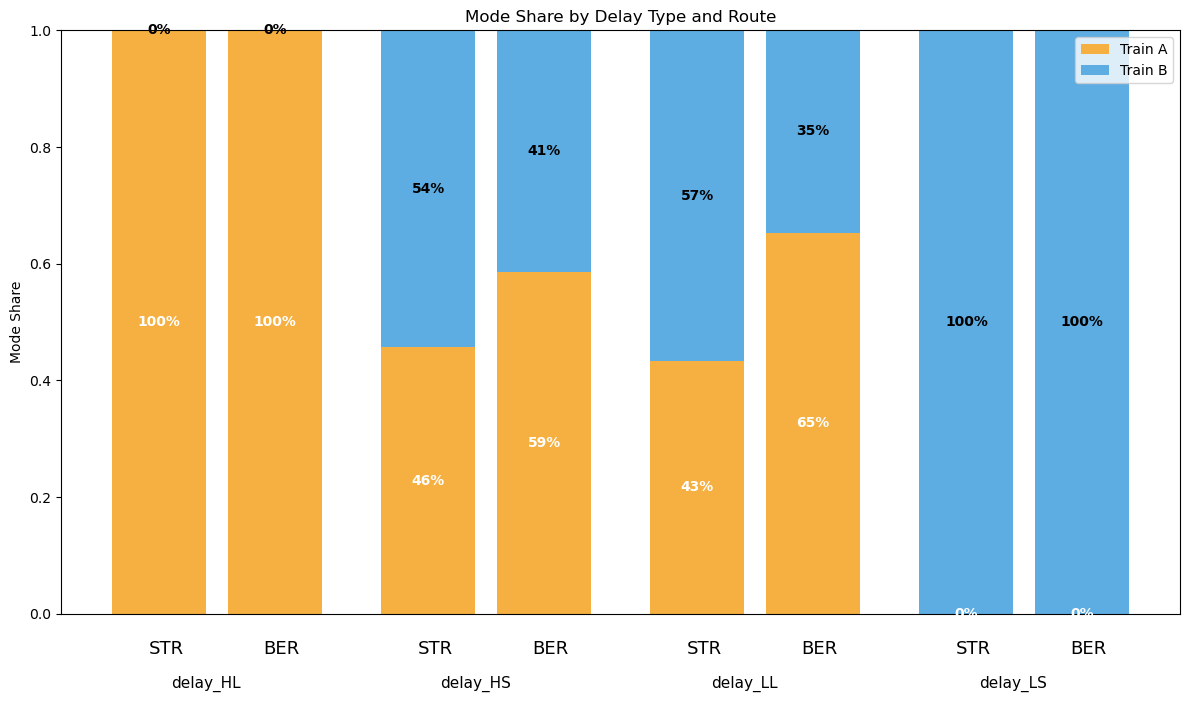

<Figure size 640x480 with 0 Axes>

In [151]:
import matplotlib.pyplot as plt
import numpy as np

# Variables
delay_types = ['delay_HL', 'delay_HS', 'delay_LL', 'delay_LS']
routes = ['STR', 'BER']

# Prepare data for plotting as before
str_shares_a = [mode_share['STR'][d][0] for d in delay_types]
str_shares_b = [mode_share['STR'][d][1] for d in delay_types]
ber_shares_a = [mode_share['BER'][d][0] for d in delay_types]
ber_shares_b = [mode_share['BER'][d][1] for d in delay_types]

bar_width = 0.35
gap = 0.08
x = np.arange(len(delay_types))

fig, ax = plt.subplots(figsize=(12, 7))

# Plot STR bars
rects1 = ax.bar(x, str_shares_a, bar_width, label='Train A', color="#F5B041")
rects2 = ax.bar(x, str_shares_b, bar_width, bottom=str_shares_a, label='Train B', color="#5DADE2")
# Plot BER bars
rects3 = ax.bar(x + bar_width + gap, ber_shares_a, bar_width, color="#F5B041")
rects4 = ax.bar(x + bar_width + gap, ber_shares_b, bar_width, bottom=ber_shares_a, color="#5DADE2")

# Annotate percentages on bars
def annotate_bars(rects, shares_a, shares_b):
    for rect, a, b in zip(rects, shares_a, shares_b):
        if not np.isnan(a):
            ax.text(rect.get_x() + rect.get_width()/2., a/2, f'{a*100:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
        if not np.isnan(b):
            ax.text(rect.get_x() + rect.get_width()/2., a + b/2, f'{b*100:.0f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

annotate_bars(rects1, str_shares_a, str_shares_b)
annotate_bars(rects3, ber_shares_a, ber_shares_b)

# Remove the default x-ticks
ax.set_xticks([])

# Manually add STR, BER, and delay labels under each bar
'''
for idx, delay in enumerate(delay_types):
    # STR
    xpos = x[idx] + bar_width/2
    ax.text(xpos, -0.06, "STR",ypos, -0.06, ha='center', va='center', fontsize=13, transform=ax.get_xaxis_transform())
    ax.text(xpos, -0.12, delay, ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())
    # BER
    xpos_ber = x[idx] + bar_width + gap + bar_width/2
    ax.text(xpos_ber, -0.06, "BER",ypos, -0.06, ha='center', va='center', fontsize=13, transform=ax.get_xaxis_transform())
    #ax.text(xpos_ber, -0.12, delay, ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())
'''
shift_amt = 0.15  # Adjust this value as needed for more or less shift

for idx, delay in enumerate(delay_types):
    # STR
    xpos = x[idx] + bar_width/2 - shift_amt
    ax.text(xpos, -0.06, "STR", ha='center', va='center', fontsize=13, transform=ax.get_xaxis_transform())
    ax.text(x[idx] + bar_width/2, -0.12, delay, ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())
    # BER
    xpos_ber = x[idx] + bar_width + gap + bar_width/2 - shift_amt
    ax.text(xpos_ber, -0.06, "BER", ha='center', va='center', fontsize=13, transform=ax.get_xaxis_transform())
    #ax.text(x[idx] + bar_width + gap + bar_width/2, -0.12, delay, ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())

ax.set_ylabel('Mode Share')
ax.set_title('Mode Share by Delay Type and Route')
ax.set_ylim(0, 1)
ax.legend(['Train A', 'Train B'])
plt.subplots_adjust(bottom=0.19)
plt.tight_layout()
plt.show()
plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/mode_share_by_delay_and_route.png', dpi=300, bbox_inches='tight')



In [153]:
# Assuming you already have mode_share as a dictionary for each delay, route, and train
import pandas as pd

# Prepare a list to create a DataFrame
data_for_latex = []

for delay in delay_types:
    for route in ['STR', 'BER']:
        shares_a = mode_share[route][delay][0]
        shares_b = mode_share[route][delay][1]
        data_for_latex.append({
            'Delay Type': delay,
            'Route': route,
            'Train A Share (%)': f"{shares_a*100:.2f}",
            'Train B Share (%)': f"{shares_b*100:.2f}"
        })

# Convert to DataFrame
df_latex = pd.DataFrame(data_for_latex)

# Convert DataFrame to LaTeX tabular format
latex_table = df_latex.to_latex(index=False)

print(latex_table)


\begin{tabular}{llll}
\toprule
Delay Type & Route & Train A Share (%) & Train B Share (%) \\
\midrule
delay_HL & STR & 100.00 & 0.00 \\
delay_HL & BER & 100.00 & 0.00 \\
delay_HS & STR & 45.71 & 54.29 \\
delay_HS & BER & 58.62 & 41.38 \\
delay_LL & STR & 43.38 & 56.62 \\
delay_LL & BER & 65.35 & 34.65 \\
delay_LS & STR & 0.00 & 100.00 \\
delay_LS & BER & 0.00 & 100.00 \\
\bottomrule
\end{tabular}



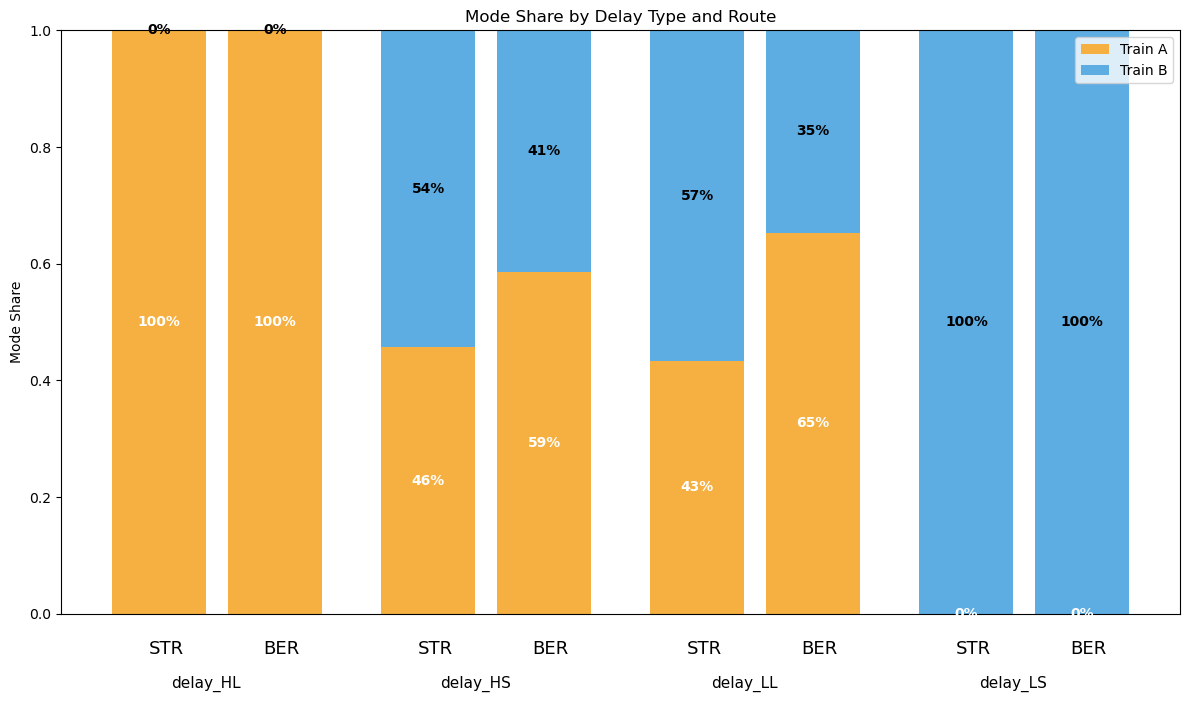

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Variables
delay_types = ['delay_HL', 'delay_HS', 'delay_LL', 'delay_LS']
routes = ['STR', 'BER']

# Prepare data for plotting as before
str_shares_a = [mode_share['STR'][d][0] for d in delay_types]
str_shares_b = [mode_share['STR'][d][1] for d in delay_types]
ber_shares_a = [mode_share['BER'][d][0] for d in delay_types]
ber_shares_b = [mode_share['BER'][d][1] for d in delay_types]

bar_width = 0.35
gap = 0.08
x = np.arange(len(delay_types))

fig, ax = plt.subplots(figsize=(12, 7))

# Plot STR bars
rects1 = ax.bar(x, str_shares_a, bar_width, label='Train A', color="#F5B041")
rects2 = ax.bar(x, str_shares_b, bar_width, bottom=str_shares_a, label='Train B', color="#5DADE2")
# Plot BER bars
rects3 = ax.bar(x + bar_width + gap, ber_shares_a, bar_width, color="#F5B041")
rects4 = ax.bar(x + bar_width + gap, ber_shares_b, bar_width, bottom=ber_shares_a, color="#5DADE2")

# Annotate percentages on bars
def annotate_bars(rects, shares_a, shares_b):
    for rect, a, b in zip(rects, shares_a, shares_b):
        if not np.isnan(a):
            ax.text(rect.get_x() + rect.get_width()/2., a/2, f'{a*100:.0f}%', ha='center', va='center', color='white', fontsize=10, fontweight='bold')
        if not np.isnan(b):
            ax.text(rect.get_x() + rect.get_width()/2., a + b/2, f'{b*100:.0f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')

annotate_bars(rects1, str_shares_a, str_shares_b)
annotate_bars(rects3, ber_shares_a, ber_shares_b)

# Remove the default x-ticks
ax.set_xticks([])

# Manually add STR, BER, and delay labels under each bar
shift_amt = 0.15  # Adjust as needed

for idx, delay in enumerate(delay_types):
    # STR
    xpos = x[idx] + bar_width/2 - shift_amt
    ax.text(xpos, -0.06, "STR", ha='center', va='center', fontsize=13, transform=ax.get_xaxis_transform())
    ax.text(x[idx] + bar_width/2, -0.12, delay, ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())
    # BER
    xpos_ber = x[idx] + bar_width + gap + bar_width/2 - shift_amt
    ax.text(xpos_ber, -0.06, "BER", ha='center', va='center', fontsize=13, transform=ax.get_xaxis_transform())

ax.set_ylabel('Mode Share')
ax.set_title('Mode Share by Delay Type and Route')
ax.set_ylim(0, 1)
ax.legend(['Train A', 'Train B'])
plt.subplots_adjust(bottom=0.19)
plt.tight_layout()

# SAVE THE FIGURE before plt.show()
plt.savefig('mode_share_by_delay_and_route.png', dpi=300, bbox_inches='tight')
plt.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/mode_share_by_delay_and_route.png', dpi=300, bbox_inches='tight')
plt.show()

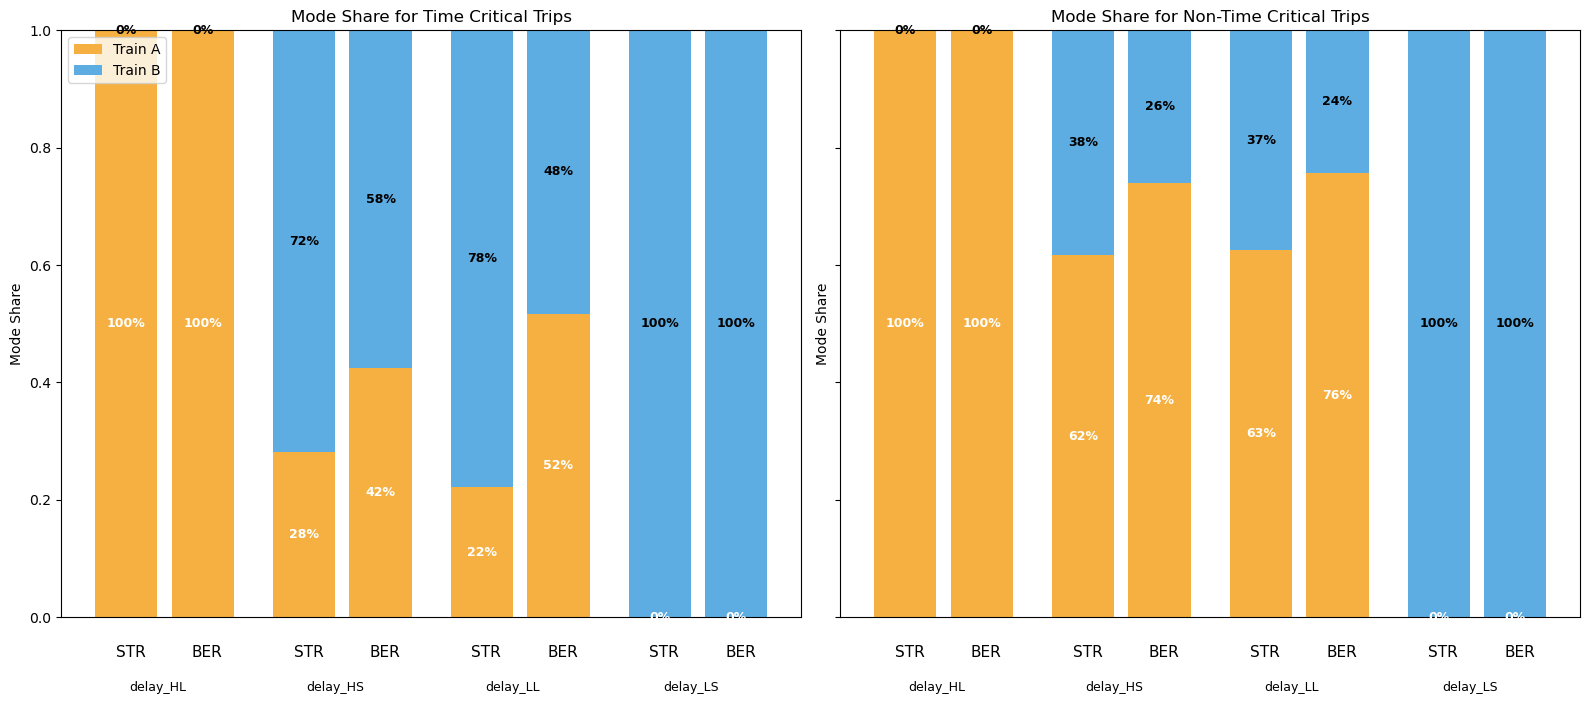

In [93]:
import matplotlib.pyplot as plt
import numpy as np

delay_types = ['delay_HL', 'delay_HS', 'delay_LL', 'delay_LS']
routes = ['STR', 'BER']

def compute_mode_shares(df, trip_purpose_col):
    mode_share = {route: {delay: [0, 0] for delay in delay_types} for route in routes}
    for route in routes:
        for delay in delay_types:
            mask = (df[route] == 1) & (df[delay] == 1) & (df[trip_purpose_col] == 1)
            subset = df[mask]
            total = len(subset)
            if total > 0:
                share_a = subset['Choice_ZugA'].sum() / total
                share_b = subset['Choice_ZugB'].sum() / total
                mode_share[route][delay] = [share_a, share_b]
            else:
                mode_share[route][delay] = [np.nan, np.nan]
    return mode_share

# Compute for TC and NTC
mode_share_tc = compute_mode_shares(df, 'TripPurpose_Time_Critical')
mode_share_ntc = compute_mode_shares(df, 'TripPurpose_Non_Time_Critical')

def plot_mode_shares(ax, mode_share, title):
    bar_width = 0.35
    gap = 0.08
    x = np.arange(len(delay_types))
    
    str_shares_a = [mode_share['STR'][d][0] for d in delay_types]
    str_shares_b = [mode_share['STR'][d][1] for d in delay_types]
    ber_shares_a = [mode_share['BER'][d][0] for d in delay_types]
    ber_shares_b = [mode_share['BER'][d][1] for d in delay_types]
    
    rects1 = ax.bar(x, str_shares_a, bar_width, label='Train A', color="#F5B041")
    rects2 = ax.bar(x, str_shares_b, bar_width, bottom=str_shares_a, label='Train B', color="#5DADE2")
    rects3 = ax.bar(x + bar_width + gap, ber_shares_a, bar_width, color="#F5B041")
    rects4 = ax.bar(x + bar_width + gap, ber_shares_b, bar_width, bottom=ber_shares_a, color="#5DADE2")
    
    def annotate_bars(rects, shares_a, shares_b):
        for rect, a, b in zip(rects, shares_a, shares_b):
            if not np.isnan(a):
                ax.text(rect.get_x() + rect.get_width()/2., a/2, f'{a*100:.0f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
            if not np.isnan(b):
                ax.text(rect.get_x() + rect.get_width()/2., a + b/2, f'{b*100:.0f}%', ha='center', va='center', color='black', fontsize=9, fontweight='bold')
    
    annotate_bars(rects1, str_shares_a, str_shares_b)
    annotate_bars(rects3, ber_shares_a, ber_shares_b)
    
    ax.set_ylim(0, 1)
    ax.set_ylabel('Mode Share')
    ax.set_title(title)
    ax.set_xticks([])
    
    shift_amt = 0.15
    for idx, delay in enumerate(delay_types):
        xpos = x[idx] + bar_width/2 - shift_amt
        ax.text(xpos, -0.06, "STR", ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())
        ax.text(x[idx] + bar_width/2, -0.12, delay, ha='center', va='center', fontsize=9, transform=ax.get_xaxis_transform())
        xpos_ber = x[idx] + bar_width + gap + bar_width/2 - shift_amt
        ax.text(xpos_ber, -0.06, "BER", ha='center', va='center', fontsize=11, transform=ax.get_xaxis_transform())

fig, axs = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
plot_mode_shares(axs[0], mode_share_tc, 'Mode Share for Time Critical Trips')
plot_mode_shares(axs[1], mode_share_ntc, 'Mode Share for Non-Time Critical Trips')

axs[0].legend(['Train A', 'Train B'], loc='upper left')
plt.subplots_adjust(bottom=0.21)
plt.tight_layout()
plt.show()

fig.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/mode_share_by_delay_route_Tpurpose.png', dpi=300, bbox_inches='tight')
plt.show()



['Response_ID', 'Set_Assigned', 'Age_Middle_Age', 'Age_Old', 'Age_Young', 'Income_High', 'Income_Low', 'Income_Middle', 'Location_Large_City', 'Location_Medium_City', 'Location_Small_City', 'Education_University', 'Education_Vocational_Non_Univ', 'Employment_Employed', 'Employment_Not_Employed_Other', 'Employment_Student_Working', 'PT_Intercity_freq_Frequent_User', 'PT_Intercity_freq_Non_User', 'PT_Intercity_freq_Occasional_User', 'PT_Intercity_freq_Rare_User', 'PT_Freq_TC_Frequent', 'PT_Freq_TC_Infrequent', 'PT_Freq_TC_Occasional', 'PT_Freq_NTC_Frequent', 'PT_Freq_NTC_Infrequent', 'PT_Freq_NTC_Occasional', 'PT_DB_IC_Frequent', 'PT_DB_IC_Infrequent', 'PT_DB_IC_Occasional', 'PT_DB_Rb_Frequent', 'PT_DB_Rb_Infrequent', 'PT_DB_Rb_Occasional', 'Coach_Frequent', 'Coach_Infrequent', 'Coach_Occasional', 'BlaBla_Frequent', 'BlaBla_Infrequent', 'BlaBla_Occasional', 'HiredCar_Infrequent', 'HiredCar_Occasional', 'PrivateCar_Frequent', 'PrivateCar_Infrequent', 'PrivateCar_Occasional', 'Flight_Infre

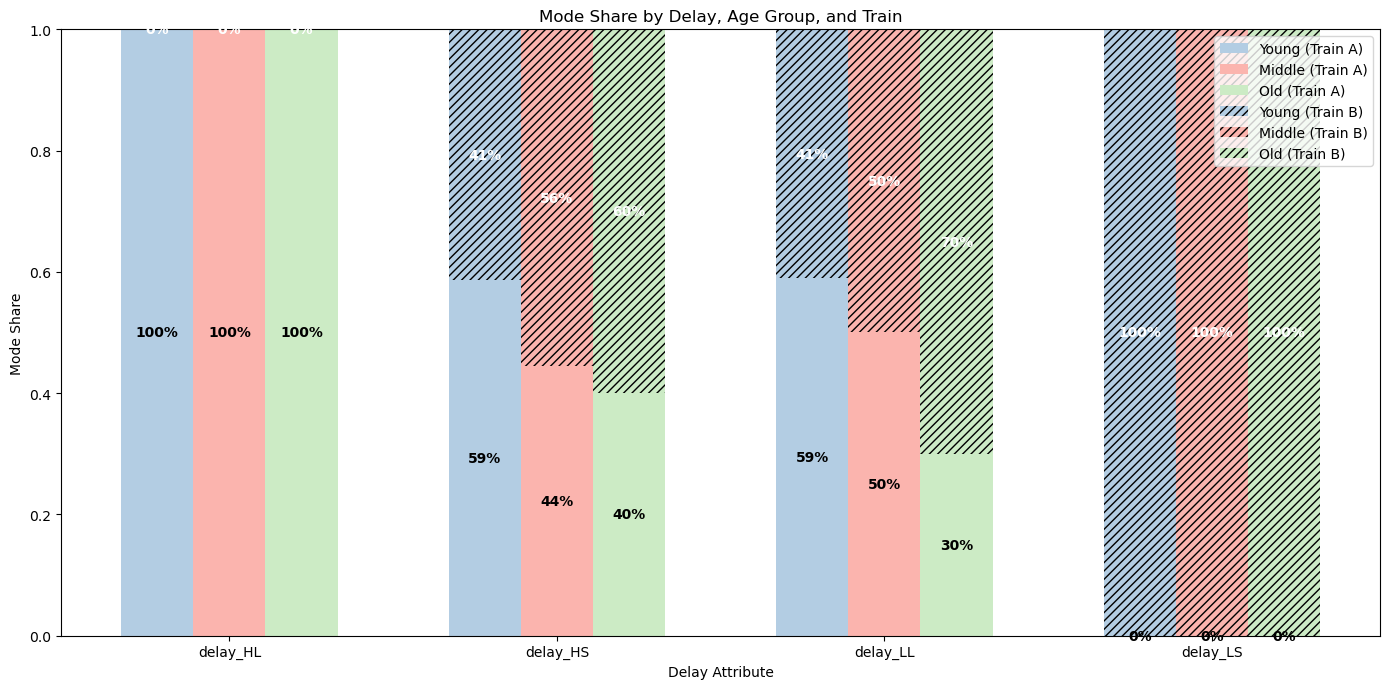

In [115]:
df = pd.read_csv('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/final_biogeme_Data_200.csv')

df.columns = [col.strip() for col in df.columns]  # Remove any whitespace from column names
print(df.columns.tolist())  # Check available column names
mask = (df[delay] == 1) & (df['Age_Young'] == 1)


delay_types = ['delay_HL', 'delay_HS', 'delay_LL', 'delay_LS']
age_groups = ['Age_Young', 'Age_Middle_Age', 'Age_Old']
age_labels = ['Young', 'Middle', 'Old']
age_colors = ['#B3CDE3', '#FBB4AE', '#CCEBC5']  # Soft blue, rose, mint

bar_width = 0.22
x = np.arange(len(delay_types))

mode_share = {delay: {age: [0, 0] for age in age_groups} for delay in delay_types}
for delay in delay_types:
    for age in age_groups:
        mask = (df[delay] == 1) & (df[age] == 1)
        subset = df[mask]
        total = len(subset)
        if total > 0:
            share_a = subset['Choice_ZugA'].sum() / total
            share_b = subset['Choice_ZugB'].sum() / total
            mode_share[delay][age] = [share_a, share_b]
        else:
            mode_share[delay][age] = [np.nan, np.nan]

fig, ax = plt.subplots(figsize=(14, 7))
for i, age in enumerate(age_groups):
    xpos = x + (i - 1) * bar_width
    shares_a = [mode_share[delay][age][0] for delay in delay_types]
    shares_b = [mode_share[delay][age][1] for delay in delay_types]
    bars_a = ax.bar(xpos, shares_a, bar_width, label=age_labels[i]+' (Train A)', color=age_colors[i])
    bars_b = ax.bar(xpos, shares_b, bar_width, bottom=shares_a, label=age_labels[i]+' (Train B)', color=age_colors[i], hatch='////')
    for j in range(len(delay_types)):
        if not np.isnan(shares_a[j]):
            ax.text(xpos[j], shares_a[j]/2, f'{shares_a[j]*100:.0f}%', ha='center', va='center', fontsize=10, color='black', fontweight='bold')
        if not np.isnan(shares_b[j]):
            ax.text(xpos[j], shares_a[j] + shares_b[j]/2, f'{shares_b[j]*100:.0f}%', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(delay_types)
ax.set_xlabel('Delay Attribute')
ax.set_ylabel('Mode Share')
ax.set_ylim(0, 1)
ax.set_title('Mode Share by Delay, Age Group, and Train')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=age_colors[i], label=f'{age_labels[i]} (Train A)') for i in range(3)]
legend_handles += [Patch(facecolor=age_colors[i], hatch='////', label=f'{age_labels[i]} (Train B)') for i in range(3)]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()


fig.savefig('/Users/syed/Downloads/Applications/Companies/Thesis/Coding/SP_Graphs/mode_share_by_delay_route_Age.png', dpi=300, bbox_inches='tight')
plt.show()
